In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Replace 'path/to/your_file.csv' with the actual path to your CSV file in Google Drive
df = pd.read_csv('/content/drive/My Drive/MedSec-25.csv')

# Display the first 5 rows of the DataFrame
display(df.head())

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,127.0.0.1-127.0.0.1-37853-41098-6,127.0.0.1,37853,127.0.0.1,41098,6,31/05/2022 12:36:00 AM,119182335,119,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
1,127.0.0.1-127.0.0.1-41098-37853-6,127.0.0.1,41098,127.0.0.1,37853,6,31/05/2022 12:36:00 AM,119182336,119,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
2,192.168.1.101-192.168.1.102-1883-49335-6,192.168.1.102,49335,192.168.1.101,1883,6,31/05/2022 12:36:00 AM,119952116,473,475,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
3,127.0.0.1-127.0.0.1-39023-57328-6,127.0.0.1,39023,127.0.0.1,57328,6,31/05/2022 12:36:01 AM,119769560,236,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign
4,127.0.0.1-127.0.0.1-57328-39023-6,127.0.0.1,57328,127.0.0.1,39023,6,31/05/2022 12:36:01 AM,119769549,236,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign


In [4]:
print(f"Total number of rows: {df.shape[0]}")
print(f"Total number of columns: {df.shape[1]}")

Total number of rows: 554534
Total number of columns: 84


In [5]:
print(df.columns)

Index(['Flow ID', 'Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol',
       'Timestamp', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE 

In [6]:
label_counts = df['Label'].value_counts()
print("Unique values and their counts in 'Label' column:")
print(label_counts)

Unique values and their counts in 'Label' column:
Label
Reconnaissance      401683
Initial access      102090
Exfiltration         25915
Lateral movement     12498
Benign               12348
Name: count, dtype: int64


In [7]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0]
missing_values = missing_values.sort_values(ascending=False)

print("Missing values per column (sorted descending):")
print(missing_values)

Missing values per column (sorted descending):
Series([], dtype: int64)


In [8]:
print("Descriptive statistics for numerical columns:")
display(df.describe())

Descriptive statistics for numerical columns:


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
count,554534.000000,554534.000000,554534.000000,5.545340e+05,554534.000000,554534.000000,5.545340e+05,5.545340e+05,554534.000000,554534.000000,...,554534.000000,554534.0,5.545340e+05,5.545340e+05,5.545340e+05,5.545340e+05,5.545340e+05,5.545340e+05,5.545340e+05,5.545340e+05
mean,49230.422447,25049.327051,6.099209,3.357517e+06,3.133916,3.330537,8.020077e+02,2.531378e+02,46.573227,1.122968,...,1.845836,0.0,1.663154e+04,4.437677e+03,2.229306e+04,1.304900e+04,2.034433e+06,1.003263e+05,2.113024e+06,1.960830e+06
std,13314.511790,21253.294177,1.164115,1.634607e+07,93.090911,24.339068,9.430435e+04,6.917782e+03,397.628235,31.704388,...,88.909447,0.0,4.933636e+05,2.099481e+05,6.371395e+05,4.431849e+05,1.207986e+07,1.948962e+06,1.241100e+07,1.192001e+07
min,0.000000,0.000000,0.000000,-1.095000e+03,0.000000,1.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,48976.000000,3374.000000,6.000000,4.453000e+03,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,54451.000000,21795.000000,6.000000,1.162300e+04,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
75%,54451.000000,44125.000000,6.000000,3.685375e+04,0.000000,2.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,...,0.000000,0.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
max,65534.000000,65535.000000,17.000000,1.200000e+08,32565.000000,4915.000000,3.700921e+07,2.663209e+06,20272.000000,4344.000000,...,32565.000000,0.0,1.120334e+08,4.683238e+07,1.120334e+08,1.120334e+08,1.200000e+08,7.668225e+07,1.200000e+08,1.200000e+08


In [9]:
print("DataFrame Info (includes data types and non-null counts):")
df.info()

print("\nData Types of all columns:")
print(df.dtypes)

DataFrame Info (includes data types and non-null counts):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 554534 entries, 0 to 554533
Data columns (total 84 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Flow ID            554534 non-null  object 
 1   Src IP             554534 non-null  object 
 2   Src Port           554534 non-null  int64  
 3   Dst IP             554534 non-null  object 
 4   Dst Port           554534 non-null  int64  
 5   Protocol           554534 non-null  int64  
 6   Timestamp          554534 non-null  object 
 7   Flow Duration      554534 non-null  int64  
 8   Tot Fwd Pkts       554534 non-null  int64  
 9   Tot Bwd Pkts       554534 non-null  int64  
 10  TotLen Fwd Pkts    554534 non-null  float64
 11  TotLen Bwd Pkts    554534 non-null  float64
 12  Fwd Pkt Len Max    554534 non-null  float64
 13  Fwd Pkt Len Min    554534 non-null  float64
 14  Fwd Pkt Len Mean   554534 non-null  float6

In [10]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month

print("DataFrame with new time-based features:")
display(df[['Timestamp', 'Hour', 'DayOfWeek', 'Month']].head())

print("\nData types of new time-based features:")
print(df[['Hour', 'DayOfWeek', 'Month']].dtypes)

/tmp/ipykernel_1899/732264476.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Timestamp'] = pd.to_datetime(df['Timestamp'])


DataFrame with new time-based features:


,Timestamp,Hour,DayOfWeek,Month
0,2022-05-31 00:36:00,0,1,5
1,2022-05-31 00:36:00,0,1,5
2,2022-05-31 00:36:00,0,1,5
3,2022-05-31 00:36:01,0,1,5
4,2022-05-31 00:36:01,0,1,5



Data types of new time-based features:
Hour         int32
DayOfWeek    int32
Month        int32
dtype: object


In [11]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], format='%Y-%m-%d %H:%M:%S')
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek
df['Month'] = df['Timestamp'].dt.month

print("DataFrame with new time-based features:")
display(df[['Timestamp', 'Hour', 'DayOfWeek', 'Month']].head())

print("\nData types of new time-based features:")
print(df[['Hour', 'DayOfWeek', 'Month']].dtypes)

DataFrame with new time-based features:


,Timestamp,Hour,DayOfWeek,Month
0,2022-05-31 00:36:00,0,1,5
1,2022-05-31 00:36:00,0,1,5
2,2022-05-31 00:36:00,0,1,5
3,2022-05-31 00:36:01,0,1,5
4,2022-05-31 00:36:01,0,1,5



Data types of new time-based features:
Hour         int32
DayOfWeek    int32
Month        int32
dtype: object


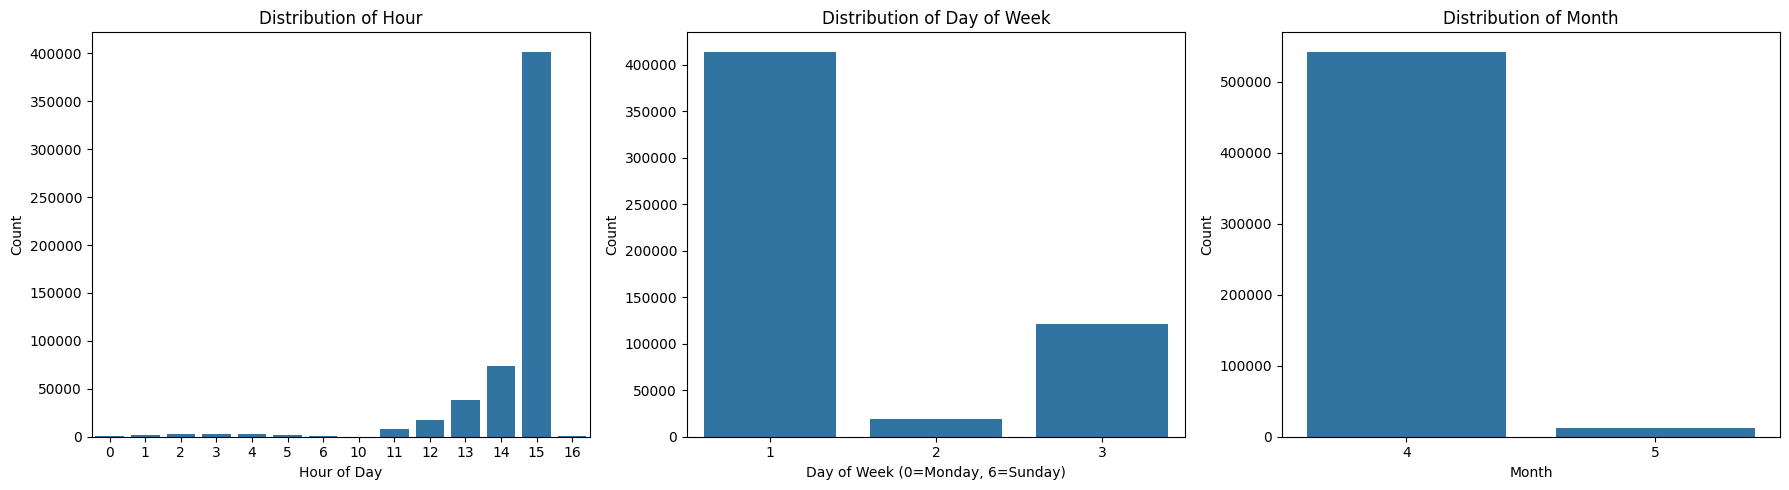

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Hour')
plt.title('Distribution of Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Count')

plt.subplot(1, 3, 2)
sns.countplot(data=df, x='DayOfWeek')
plt.title('Distribution of Day of Week')
plt.xlabel('Day of Week (0=Monday, 6=Sunday)')
plt.ylabel('Count')

plt.subplot(1, 3, 3)
sns.countplot(data=df, x='Month')
plt.title('Distribution of Month')
plt.xlabel('Month')
plt.ylabel('Count')

plt.tight_layout()
plt.show()


In [13]:
print(f"Number of unique values in 'Flow ID': {df['Flow ID'].nunique()}")
print(f"Number of unique values in 'Src IP': {df['Src IP'].nunique()}")
print(f"Number of unique values in 'Dst IP': {df['Dst IP'].nunique()}")

print("\nTop 5 most frequent values in 'Src IP' column:")
print(df['Src IP'].value_counts().head())

print("\nTop 5 most frequent values in 'Dst IP' column:")
print(df['Dst IP'].value_counts().head())

Number of unique values in 'Flow ID': 467203
Number of unique values in 'Src IP': 23
Number of unique values in 'Dst IP': 196

Top 5 most frequent values in 'Src IP' column:
Src IP
192.168.1.108    463811
192.168.1.101     26486
192.168.1.100     16976
192.168.1.104     12533
192.168.1.107      9125
Name: count, dtype: int64

Top 5 most frequent values in 'Dst IP' column:
Dst IP
192.168.1.1      178743
192.168.1.101    116385
192.168.1.102    101491
192.168.1.103     91601
192.168.1.104     30896
Name: count, dtype: int64


In [14]:
df = df.drop('Flow ID', axis=1)
print(" 'Flow ID' column dropped. Current columns:")
print(df.columns)

 'Flow ID' column dropped. Current columns:
Index(['Src IP', 'Src Port', 'Dst IP', 'Dst Port', 'Protocol', 'Timestamp',
       'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts',
       'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min',
       'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max',
       'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s',
       'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len',
       'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min',
       'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var',
       'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt',
       'ACK Flag Cnt', 'URG Flag Cnt

In [15]:
df = pd.get_dummies(df, columns=['Src IP', 'Dst IP'], prefix=['Src_IP', 'Dst_IP'])
print("DataFrame after one-hot encoding 'Src IP' and 'Dst IP' columns:")
print(df.head())

DataFrame after one-hot encoding 'Src IP' and 'Dst IP' columns:
   Src Port  Dst Port  Protocol           Timestamp  Flow Duration  \
0     37853     41098         6 2022-05-31 00:36:00      119182335   
1     41098     37853         6 2022-05-31 00:36:00      119182336   
2     49335      1883         6 2022-05-31 00:36:00      119952116   
3     39023     57328         6 2022-05-31 00:36:01      119769560   
4     57328     39023         6 2022-05-31 00:36:01      119769549   

   Tot Fwd Pkts  Tot Bwd Pkts  TotLen Fwd Pkts  TotLen Bwd Pkts  \
0           119             1            119.0              1.0   
1           119             1              0.0              0.0   
2           473           475          38978.0             82.0   
3           236             1            236.0              1.0   
4           236             1              0.0              0.0   

   Fwd Pkt Len Max  ...  Dst_IP_255.255.255.255  Dst_IP_34.90.4.226  \
0              1.0  ...                  

In [16]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
le = LabelEncoder()

# Apply LabelEncoder to the 'Label' column
df['Label'] = le.fit_transform(df['Label'])

print("DataFrame with encoded 'Label' column:")
display(df[['Label']].head())

print("\nMapping of original labels to encoded numerical values:")
for i, label in enumerate(le.classes_):
    print(f"{label}: {i}")

DataFrame with encoded 'Label' column:


,Label
0,0
1,0
2,0
3,0
4,0



Mapping of original labels to encoded numerical values:
Benign: 0
Exfiltration: 1
Initial access: 2
Lateral movement: 3
Reconnaissance: 4


In [17]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
# Exclude 'Timestamp' (already handled), 'Label' (target), 'Hour', 'DayOfWeek', 'Month' (already extracted)
numerical_cols = df.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()

# Remove 'Label', 'Hour', 'DayOfWeek', 'Month' from the list of columns to scale
columns_to_exclude = ['Label', 'Hour', 'DayOfWeek', 'Month']
numerical_cols = [col for col in numerical_cols if col not in columns_to_exclude]

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit and transform the selected numerical columns
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("DataFrame after scaling numerical features:")
display(df[numerical_cols].head())

DataFrame after scaling numerical features:


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Fwd Act Data Pkts,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,-0.854514,0.755115,-0.085223,7.085795,1.244656,-0.095753,-0.007243,-0.036448,-0.114613,-0.003879,...,1.317681,0.0,-0.033711,-0.021137,-0.034989,-0.029444,-0.168415,-0.051477,-0.170254,-0.164499
1,-0.610794,0.602433,-0.085223,7.085795,1.244656,-0.095753,-0.008504,-0.036592,-0.117128,-0.035420,...,-0.020761,0.0,-0.033711,-0.021137,-0.034989,-0.029444,-0.168415,-0.051477,-0.170254,-0.164499
2,0.007854,-1.090012,-0.085223,7.132888,5.047394,19.379127,0.404817,-0.024739,0.094125,2.519434,...,5.299264,0.0,-0.033711,-0.021137,-0.034989,-0.029444,-0.168415,-0.051477,-0.170254,-0.164499
3,-0.766640,1.518762,-0.085223,7.121719,2.501493,-0.095753,-0.006002,-0.036448,-0.114613,-0.003879,...,2.633628,0.0,-0.033711,-0.021137,-0.034989,-0.029444,-0.168415,-0.051477,-0.170254,-0.164499
4,0.608177,0.657483,-0.085223,7.121719,2.501493,-0.095753,-0.008504,-0.036592,-0.117128,-0.035420,...,-0.020761,0.0,-0.033711,-0.021137,-0.034989,-0.029444,-0.168415,-0.051477,-0.170254,-0.164499


In [18]:
df = df.drop('Timestamp', axis=1)
print(" 'Timestamp' column dropped. Current columns:")
print(df.columns)

 'Timestamp' column dropped. Current columns:
Index(['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts',
       'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min',
       ...
       'Dst_IP_255.255.255.255', 'Dst_IP_34.90.4.226', 'Dst_IP_38.139.0.47',
       'Dst_IP_38.139.0.85', 'Dst_IP_73.126.4.216', 'Dst_IP_8.0.6.4',
       'Dst_IP_89.65.0.47', 'Dst_IP_89.65.0.85', 'Dst_IP_90.187.0.47',
       'Dst_IP_90.187.0.85'],
      dtype='object', length=302)


In [19]:
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Label', axis=1)
y = df['Label']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

print("\nFirst 5 rows of X_train:")
display(X_train.head())

Shape of X_train: (443627, 301)
Shape of X_test: (110907, 301)
Shape of y_train: (443627,)
Shape of y_test: (110907,)

First 5 rows of X_train:


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Dst_IP_255.255.255.255,Dst_IP_34.90.4.226,Dst_IP_38.139.0.47,Dst_IP_38.139.0.85,Dst_IP_73.126.4.216,Dst_IP_8.0.6.4,Dst_IP_89.65.0.47,Dst_IP_89.65.0.85,Dst_IP_90.187.0.47,Dst_IP_90.187.0.85
57902,0.440165,-1.090012,-0.085223,-0.040697,0.052272,0.150764,-0.007296,-0.035291,0.114244,-0.03542,...,False,False,False,False,False,False,False,False,False,False
438394,0.392097,0.130270,-0.085223,-0.204697,-0.033665,-0.054667,-0.008504,-0.036592,-0.117128,-0.03542,...,False,False,False,False,False,False,False,False,False,False
231007,0.392097,0.318571,-0.085223,-0.204711,-0.033665,-0.054667,-0.008504,-0.036592,-0.117128,-0.03542,...,False,False,False,False,False,False,False,False,False,False
445390,-1.005477,0.758409,-0.085223,-0.204975,-0.033665,-0.054667,-0.008504,-0.036592,-0.117128,-0.03542,...,False,False,False,False,False,False,False,False,False,False
253678,0.702661,-1.176116,-0.085223,-0.106542,-0.001439,0.068592,-0.008504,-0.036592,-0.117128,-0.03542,...,False,False,False,False,False,False,False,False,False,False


In [20]:
engineered_features = ['Hour', 'DayOfWeek', 'Month']

# Add one-hot encoded IP columns
for col in X_train.columns:
    if col.startswith('Src_IP_') or col.startswith('Dst_IP_'):
        engineered_features.append(col)

# Ensure all identified engineered features are in the DataFrame before proceeding
# Concatenate X_train and y_train for correlation calculation
df_train_correlated = pd.concat([X_train, y_train], axis=1)

# Calculate correlations with the 'Label' column
correlations = df_train_correlated[engineered_features].corrwith(df_train_correlated['Label'])

# Sort by absolute value in descending order
sorted_correlations = correlations.abs().sort_values(ascending=False)

print("Correlation of engineered features with 'Label' (sorted by absolute value):\n")
print(sorted_correlations)


/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Correlation of engineered features with 'Label' (sorted by absolute value):

DayOfWeek                 0.749011
Src_IP_192.168.1.108      0.549992
Hour                      0.531402
Month                     0.475375
Src_IP_192.168.1.101      0.454228
                            ...   
Dst_IP_192.168.172.201         NaN
Dst_IP_192.168.173.152         NaN
Dst_IP_192.168.173.250         NaN
Dst_IP_192.168.175.95          NaN
Dst_IP_38.139.0.85             NaN
Length: 222, dtype: float64


In [21]:
from sklearn.preprocessing import StandardScaler

# Identify numerical columns to scale
# Reuse the numerical_cols list that was created previously, ensuring it excludes 'Label', 'Hour', 'DayOfWeek', 'Month'
# This list contains all original numerical columns plus one-hot encoded IP columns, excluding the ones already processed.

# The numerical_cols list in the kernel state is:
# ['Src Port', 'Dst Port', 'Protocol', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts', 'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std', 'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean', 'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s', 'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean', 'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt', 'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt', 'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg', 'Fwd Seg Size Avg', 'Bwd Seg Size Avg', 'Fwd Byts/b Avg', 'Fwd Pkts/b Avg', 'Fwd Blk Rate Avg', 'Bwd Byts/b Avg', 'Bwd Pkts/b Avg', 'Bwd Blk Rate Avg', 'Subflow Fwd Pkts', 'Subflow Fwd Byts', 'Subflow Bwd Pkts', 'Subflow Bwd Byts', 'Init Fwd Win Byts', 'Init Bwd Win Byts', 'Fwd Act Data Pkts', 'Fwd Seg Size Min', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']

# We also need to include the one-hot encoded IP columns in the numerical_cols list
# All columns in X_train are numerical, except for 'Label' (which is y) and the time-based features and original IP cols.
# We should get the numerical columns to scale directly from X_train's columns, since it now contains all features suitable for scaling.

# Create a list of columns to scale from X_train, excluding those that were specifically handled (like time features already created).
# At this point, X_train contains all features that should be scaled, except for the 'Hour', 'DayOfWeek', 'Month' which were already integer type and were handled differently if needed.

# The numerical_cols variable in the kernel state is actually the list of numerical columns before one-hot encoding IP addresses.
# After one-hot encoding, X_train contains all features that need to be scaled or are already suitable (like 'Hour', 'DayOfWeek', 'Month').
# The problem is that the previously scaled columns were not explicitly stored.

# Let's redefine numerical_cols to include all columns in X_train that were initially numerical and were scaled,
# as well as the new one-hot encoded IP columns.
# The features 'Hour', 'DayOfWeek', 'Month' are already correctly handled (integer types).
# The current X_train dataframe already contains the features that need scaling.
# The 'numerical_cols' variable in the kernel state was derived from `df.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()` before dropping 'Timestamp' and before one-hot encoding.
# To correctly identify the columns to scale from X_train, we should consider all its columns EXCEPT 'Hour', 'DayOfWeek', 'Month' which are treated as discrete integers.

columns_to_not_scale_in_X = ['Hour', 'DayOfWeek', 'Month']
scaled_numerical_cols = [col for col in X_train.columns if col not in columns_to_not_scale_in_X]

# Instantiate StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data (X_train) and transform it
X_train[scaled_numerical_cols] = scaler.fit_transform(X_train[scaled_numerical_cols])

# Transform the testing data (X_test) using the fitted scaler
X_test[scaled_numerical_cols] = scaler.transform(X_test[scaled_numerical_cols])

print("X_train after re-scaling numerical features (first 5 rows of scaled columns):")
display(X_train[scaled_numerical_cols].head())

print("\nX_test after re-scaling numerical features (first 5 rows of scaled columns):")
display(X_test[scaled_numerical_cols].head())

X_train after re-scaling numerical features (first 5 rows of scaled columns):


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Dst_IP_255.255.255.255,Dst_IP_34.90.4.226,Dst_IP_38.139.0.47,Dst_IP_38.139.0.85,Dst_IP_73.126.4.216,Dst_IP_8.0.6.4,Dst_IP_89.65.0.47,Dst_IP_89.65.0.85,Dst_IP_90.187.0.47,Dst_IP_90.187.0.85
57902,0.440514,-1.089921,-0.085019,-0.040800,0.048400,0.158768,-0.007186,-0.033426,0.113032,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
438394,0.392382,0.129684,-0.085019,-0.204834,-0.031650,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
231007,0.392382,0.317880,-0.085019,-0.204847,-0.031650,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
445390,-1.007028,0.757474,-0.085019,-0.205112,-0.031650,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
253678,0.703354,-1.175977,-0.085019,-0.106658,-0.001631,0.072572,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501



X_test after re-scaling numerical features (first 5 rows of scaled columns):


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Dst_IP_255.255.255.255,Dst_IP_34.90.4.226,Dst_IP_38.139.0.47,Dst_IP_38.139.0.85,Dst_IP_73.126.4.216,Dst_IP_8.0.6.4,Dst_IP_89.65.0.47,Dst_IP_89.65.0.85,Dst_IP_90.187.0.47,Dst_IP_90.187.0.85
418506,0.392382,-0.921852,-0.085019,-0.205094,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
304352,-3.696577,0.477390,-0.085019,-0.205530,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
520965,0.666353,0.866667,-0.085019,-0.205199,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
247666,0.392382,-0.913622,-0.085019,-0.202991,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
284318,0.666353,0.111485,-0.085019,-0.205152,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501


In [22]:
leaking_features = ['DayOfWeek', 'Hour', 'Src_IP_192.168.1.108']

# Create a new DataFrame X_reduced by dropping these features from X
X_reduced = X.drop(columns=leaking_features, errors='ignore')

print(f"Shape of X_reduced after removing leaking features: {X_reduced.shape}")

print("First 5 rows of X_reduced:")
display(X_reduced.head())

Shape of X_reduced after removing leaking features: (554534, 298)
First 5 rows of X_reduced:


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Dst_IP_255.255.255.255,Dst_IP_34.90.4.226,Dst_IP_38.139.0.47,Dst_IP_38.139.0.85,Dst_IP_73.126.4.216,Dst_IP_8.0.6.4,Dst_IP_89.65.0.47,Dst_IP_89.65.0.85,Dst_IP_90.187.0.47,Dst_IP_90.187.0.85
0,-0.854514,0.755115,-0.085223,7.085795,1.244656,-0.095753,-0.007243,-0.036448,-0.114613,-0.003879,...,False,False,False,False,False,False,False,False,False,False
1,-0.610794,0.602433,-0.085223,7.085795,1.244656,-0.095753,-0.008504,-0.036592,-0.117128,-0.035420,...,False,False,False,False,False,False,False,False,False,False
2,0.007854,-1.090012,-0.085223,7.132888,5.047394,19.379127,0.404817,-0.024739,0.094125,2.519434,...,False,False,False,False,False,False,False,False,False,False
3,-0.766640,1.518762,-0.085223,7.121719,2.501493,-0.095753,-0.006002,-0.036448,-0.114613,-0.003879,...,False,False,False,False,False,False,False,False,False,False
4,0.608177,0.657483,-0.085223,7.121719,2.501493,-0.095753,-0.008504,-0.036592,-0.117128,-0.035420,...,False,False,False,False,False,False,False,False,False,False


In [23]:
from sklearn.model_selection import train_test_split

# Split the data with reduced features into training and testing sets
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train_reduced: {X_train_reduced.shape}")
print(f"Shape of X_test_reduced: {X_test_reduced.shape}")
print(f"Shape of y_train_reduced: {y_train_reduced.shape}")
print(f"Shape of y_test_reduced: {y_test_reduced.shape}")

print("\nFirst 5 rows of X_train_reduced:")
display(X_train_reduced.head())

Shape of X_train_reduced: (443627, 298)
Shape of X_test_reduced: (110907, 298)
Shape of y_train_reduced: (443627,)
Shape of y_test_reduced: (110907,)

First 5 rows of X_train_reduced:


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Dst_IP_255.255.255.255,Dst_IP_34.90.4.226,Dst_IP_38.139.0.47,Dst_IP_38.139.0.85,Dst_IP_73.126.4.216,Dst_IP_8.0.6.4,Dst_IP_89.65.0.47,Dst_IP_89.65.0.85,Dst_IP_90.187.0.47,Dst_IP_90.187.0.85
57902,0.440165,-1.090012,-0.085223,-0.040697,0.052272,0.150764,-0.007296,-0.035291,0.114244,-0.03542,...,False,False,False,False,False,False,False,False,False,False
438394,0.392097,0.130270,-0.085223,-0.204697,-0.033665,-0.054667,-0.008504,-0.036592,-0.117128,-0.03542,...,False,False,False,False,False,False,False,False,False,False
231007,0.392097,0.318571,-0.085223,-0.204711,-0.033665,-0.054667,-0.008504,-0.036592,-0.117128,-0.03542,...,False,False,False,False,False,False,False,False,False,False
445390,-1.005477,0.758409,-0.085223,-0.204975,-0.033665,-0.054667,-0.008504,-0.036592,-0.117128,-0.03542,...,False,False,False,False,False,False,False,False,False,False
253678,0.702661,-1.176116,-0.085223,-0.106542,-0.001439,0.068592,-0.008504,-0.036592,-0.117128,-0.03542,...,False,False,False,False,False,False,False,False,False,False


In [24]:
from sklearn.preprocessing import StandardScaler

# Instantiate StandardScaler
scaler_reduced = StandardScaler()

# Identify numerical columns to scale in the reduced dataset
# All columns in X_train_reduced are numerical now and need scaling
scaled_numerical_cols_reduced = X_train_reduced.columns.tolist()

# Fit the scaler on the training data (X_train_reduced) and transform it
X_train_reduced[scaled_numerical_cols_reduced] = scaler_reduced.fit_transform(X_train_reduced[scaled_numerical_cols_reduced])

# Transform the testing data (X_test_reduced) using the fitted scaler
X_test_reduced[scaled_numerical_cols_reduced] = scaler_reduced.transform(X_test_reduced[scaled_numerical_cols_reduced])

print("X_train_reduced after re-scaling numerical features (first 5 rows):")
display(X_train_reduced.head())

print("\nX_test_reduced after re-scaling numerical features (first 5 rows):")
display(X_test_reduced.head())

X_train_reduced after re-scaling numerical features (first 5 rows):


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Dst_IP_255.255.255.255,Dst_IP_34.90.4.226,Dst_IP_38.139.0.47,Dst_IP_38.139.0.85,Dst_IP_73.126.4.216,Dst_IP_8.0.6.4,Dst_IP_89.65.0.47,Dst_IP_89.65.0.85,Dst_IP_90.187.0.47,Dst_IP_90.187.0.85
57902,0.440514,-1.089921,-0.085019,-0.040800,0.048400,0.158768,-0.007186,-0.033426,0.113032,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
438394,0.392382,0.129684,-0.085019,-0.204834,-0.031650,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
231007,0.392382,0.317880,-0.085019,-0.204847,-0.031650,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
445390,-1.007028,0.757474,-0.085019,-0.205112,-0.031650,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
253678,0.703354,-1.175977,-0.085019,-0.106658,-0.001631,0.072572,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501



X_test_reduced after re-scaling numerical features (first 5 rows):


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Dst_IP_255.255.255.255,Dst_IP_34.90.4.226,Dst_IP_38.139.0.47,Dst_IP_38.139.0.85,Dst_IP_73.126.4.216,Dst_IP_8.0.6.4,Dst_IP_89.65.0.47,Dst_IP_89.65.0.85,Dst_IP_90.187.0.47,Dst_IP_90.187.0.85
418506,0.392382,-0.921852,-0.085019,-0.205094,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
304352,-3.696577,0.477390,-0.085019,-0.205530,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
520965,0.666353,0.866667,-0.085019,-0.205199,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
247666,0.392382,-0.913622,-0.085019,-0.202991,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
284318,0.666353,0.111485,-0.085019,-0.205152,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501


# Task
Check the class distribution of the target variable `y_train_reduced`, apply SMOTE to `X_train_reduced` and `y_train_reduced`, and then verify the new class distribution of the resampled training data to confirm that the class imbalance has been successfully addressed.

## Check Class Distribution (Reduced Training Data)

### Subtask:
Examine and print the class distribution of the target variable `y_train_reduced` to confirm the extent of the class imbalance in the training set after feature reduction.


**Reasoning**:
To understand the class distribution in the reduced training set, I will use the `value_counts()` method on the `y_train_reduced` Series and print the result.



In [25]:
print("Class distribution in y_train_reduced:")
print(y_train_reduced.value_counts())

Class distribution in y_train_reduced:
Label
4    321346
2     81672
1     20732
3      9998
0      9879
Name: count, dtype: int64


# Task
To meet the runtime constraints, create a small, representative subset (e.g., 5%) of `X_train_reduced` and `y_train_reduced` for feature selection, named `X_train_puma` and `y_train_puma` respectively. Ensure the class distribution is preserved in this downsampled data.

## Downsample Training Data for Faster Puma Evaluation

### Subtask:
To meet the runtime constraints, create a small, representative subset (e.g., 5%) of `X_train_reduced` and `y_train_reduced` for feature selection, named `X_train_puma` and `y_train_puma` respectively. Ensure the class distribution is preserved in this downsampled data.


**Reasoning**:
The subtask requires creating a downsampled subset of the training data (`X_train_reduced`, `y_train_reduced`) for feature selection, maintaining class distribution. I will use `train_test_split` to achieve this, specifying `test_size=0.05` for a 5% subset, `stratify=y_train_reduced` to preserve class distribution, and `random_state=42` for reproducibility.



In [26]:
from sklearn.model_selection import train_test_split

# Split the data to create a 5% subset for Puma evaluation
# The first two outputs are the larger training set (95%), which we don't need to store for this specific task.
_, X_train_puma, _, y_train_puma = train_test_split(X_train_reduced, y_train_reduced, test_size=0.05, random_state=42, stratify=y_train_reduced)

print(f"Shape of X_train_puma: {X_train_puma.shape}")
print(f"Shape of y_train_puma: {y_train_puma.shape}")

print("\nFirst 5 rows of X_train_puma:")
display(X_train_puma.head())

Shape of X_train_puma: (22182, 298)
Shape of y_train_puma: (22182,)

First 5 rows of X_train_puma:


,Src Port,Dst Port,Protocol,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Dst_IP_255.255.255.255,Dst_IP_34.90.4.226,Dst_IP_38.139.0.47,Dst_IP_38.139.0.85,Dst_IP_73.126.4.216,Dst_IP_8.0.6.4,Dst_IP_89.65.0.47,Dst_IP_89.65.0.85,Dst_IP_90.187.0.47,Dst_IP_90.187.0.85
323879,-1.007028,1.488531,-0.085019,-0.205106,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
452571,0.392382,1.681524,-0.085019,-0.204785,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
250154,0.392382,1.261398,-0.085019,-0.204683,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
447290,0.392382,-0.120350,-0.085019,-0.205049,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501
309470,0.666353,0.081530,-0.085019,-0.205274,-0.03165,-0.056721,-0.008278,-0.034642,-0.117752,-0.034685,...,-0.002123,-0.001501,-0.001501,0.0,-0.001501,-0.021762,-0.001501,-0.001501,-0.001501,-0.001501


## Simplify Objective Function for Chaotic Puma

### Subtask:
Instead of full cross-validation, define a very fast objective function. This could involve a single train-validation split (e.g., 80/20) on the downsampled data and a *very lightweight* model (e.g., Logistic Regression with limited iterations, or a Decision Tree with max_depth=3) to quickly evaluate feature subsets. The goal is speed, not optimal evaluation.


**Reasoning**:
First, I will import the necessary libraries for model selection (train_test_split) and a lightweight classification model (LogisticRegression) to prepare for defining the objective function.



In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

**Reasoning**:
Now that the necessary libraries are imported, I will define the `evaluate_subset` function as described in the subtask instructions. This function will perform a train-validation split on the selected features, train a lightweight Logistic Regression model, and return its accuracy.



In [28]:
def evaluate_subset(X_data, y_data, feature_indices):
    # Select features based on the given indices
    X_subset = X_data.iloc[:, feature_indices]

    # Perform a single train-validation split (e.g., 80/20)
    X_train_split, X_val_split, y_train_split, y_val_split = train_test_split(
        X_subset, y_data, test_size=0.2, random_state=42, stratify=y_data
    )

    # Instantiate a lightweight Logistic Regression model
    # Using 'liblinear' solver for small datasets and 'max_iter=100' for speed
    model = LogisticRegression(max_iter=100, solver='liblinear', random_state=42)

    # Train the model
    model.fit(X_train_split, y_train_split)

    # Make predictions on the validation set
    y_pred = model.predict(X_val_split)

    # Calculate accuracy score
    accuracy = accuracy_score(y_val_split, y_pred)

    return accuracy

print("The 'evaluate_subset' function has been defined.")

The 'evaluate_subset' function has been defined.


**Reasoning**:
The first step in implementing the Chaotic Puma algorithm is to define the required parameters and initialize the population of 'pumas'. This involves setting the population size and number of iterations, and then creating a set of random binary feature subsets.



In [32]:
import numpy as np

# 1. Define the parameters for the Chaotic Puma algorithm
population_size = 15  # Small population size for aggressive time limits
num_iterations = 20    # Minimal iterations for aggressive time limits
num_features = X_train_puma.shape[1]

# 2. Initialize the population
# Each puma is a binary array representing a feature subset
# Randomly initialize by selecting a small percentage of features (e.g., 10%) to be '1'
population = []
for _ in range(population_size):
    # Create a random binary array
    # For a small percentage of features to be 1, we can use np.random.rand
    # and set a threshold (e.g., 0.1 for 10% features)
    puma = (np.random.rand(num_features) < 0.1).astype(int)
    # Ensure at least one feature is selected to avoid empty subsets if randomization is too sparse
    if np.sum(puma) == 0:
        puma[np.random.randint(0, num_features)] = 1
    population.append(puma)

print(f"Chaotic Puma parameters defined: Population Size = {population_size}, Number of Iterations = {num_iterations}")
print(f"Initialized population with {len(population)} pumas, each with {num_features} features.")
print("Example of a puma's feature selection (first 10 features):")
print(population[0][:10])

Chaotic Puma parameters defined: Population Size = 15, Number of Iterations = 20
Initialized population with 15 pumas, each with 298 features.
Example of a puma's feature selection (first 10 features):
[0 0 0 0 0 0 0 0 0 0]


**Reasoning**:
Now that the population is initialized, I will initialize the personal bests for each puma and the global best found so far by evaluating each puma in the initial population. This involves calling the `evaluate_subset` function for each puma to determine its initial score.



In [33]:
pbest_positions = []
pbest_scores = np.full(population_size, -np.inf) # Initialize with negative infinity for maximizing accuracy

gbest_position = None
gbest_score = -np.inf

for i, puma in enumerate(population):
    # Convert binary puma to feature indices
    feature_indices = np.where(puma == 1)[0].tolist()

    if not feature_indices: # Handle cases where a puma might have no features selected (though previous step tried to prevent this)
        current_score = -np.inf # Assign a very low score if no features are selected
    else:
        current_score = evaluate_subset(X_train_puma, y_train_puma, feature_indices)

    # Update personal best
    if current_score > pbest_scores[i]:
        pbest_scores[i] = current_score
        pbest_positions.append(puma) # Store the numpy array
    else: # If current score is not better, still append the original puma to keep list length consistent
        pbest_positions.append(puma) # This ensures pbest_positions has one entry per puma initially

    # Update global best
    if current_score > gbest_score:
        gbest_score = current_score
        gbest_position = puma.copy() # Store a copy of the numpy array

# Ensure pbest_positions is a list of numpy arrays, one for each puma
# The above logic correctly adds each puma to pbest_positions for the first iteration.

print(f"Initial Global Best Score: {gbest_score:.4f}")
print(f"Initial Global Best Position (first 10 features): {gbest_position[:10] if gbest_position is not None else 'None'}")
print(f"Number of pbest_positions initialized: {len(pbest_positions)}")

Initial Global Best Score: 0.8208
Initial Global Best Position (first 10 features): [0 0 1 0 0 0 0 0 0 0]
Number of pbest_positions initialized: 15


**Reasoning**:
The next step is to implement the main Chaotic Puma algorithm loop, which involves iterating for a predefined number of times, evaluating each puma's feature subset, updating personal and global best scores, and updating the pumas' positions using a chaotic perturbation strategy as outlined in the subtask.



In [34]:
import numpy as np

# Initialize pbest_positions with the initial population (from previous step)
pbest_positions = [p.copy() for p in population]
# pbest_scores and gbest_score/position were initialized in the previous step

# Initialize chaotic variables for each puma (required for step 4.a.iii)
# Using a small non-zero, non-one random value for x0 to avoid fixed points
# Reinitialize to ensure fresh chaotic sequences if this cell is re-run independently
chaotic_variables = np.random.uniform(0.01, 0.99, population_size)

print("Starting Chaotic Puma iterations...")
for iteration in range(num_iterations):
    print(f"\nIteration {iteration + 1}/{num_iterations}")

    # Evaluate current population and update pbest, gbest for the *current* population states
    for i, puma in enumerate(population):
        feature_indices = np.where(puma == 1)[0].tolist()

        if not feature_indices: # Handle case where no features are selected
            current_score = -np.inf # Assign a very low score
        else:
            current_score = evaluate_subset(X_train_puma, y_train_puma, feature_indices)

        # Update personal best for puma 'i'
        if current_score > pbest_scores[i]:
            pbest_scores[i] = current_score
            pbest_positions[i] = puma.copy() # Store the current best position for this puma

        # Update global best
        if current_score > gbest_score:
            gbest_score = current_score
            gbest_position = puma.copy()

    # After evaluating all pumas and updating pbest/gbest, then update puma positions for the next iteration
    for i in range(population_size):
        # Update chaotic variable for this puma using logistic map
        chaotic_variables[i] = 4 * chaotic_variables[i] * (1 - chaotic_variables[i])

        new_puma = population[i].copy()
        for j in range(num_features):
            r = np.random.rand()

            # Simplified probabilistic update combining pbest, gbest and chaotic exploration
            # These probabilities are heuristic and can be tuned.
            prob_move_towards_pbest = 0.4
            prob_move_towards_gbest = 0.5
            # chaotic_variables[i] provides a value between (0, 1), so 0.1 * chaotic_variables[i] is a small probability
            prob_chaotic_flip = 0.1 * chaotic_variables[i]

            if r < prob_move_towards_pbest: # Bias towards personal best
                new_puma[j] = pbest_positions[i][j]
            elif r < prob_move_towards_pbest + prob_move_towards_gbest: # Bias towards global best
                new_puma[j] = gbest_position[j]
            elif r < prob_move_towards_pbest + prob_move_towards_gbest + prob_chaotic_flip: # Chaotic exploration
                new_puma[j] = 1 - new_puma[j] # Flip the bit

        # Ensure at least one feature is selected to avoid empty subsets
        if np.sum(new_puma) == 0:
            new_puma[np.random.randint(0, num_features)] = 1

        population[i] = new_puma.copy()

    print(f"Iteration {iteration + 1} completed. Current Global Best Score: {gbest_score:.4f}")

# After the loop, the gbest_position contains the best feature subset found.
# Convert it to list of indices.
final_selected_features_indices = np.where(gbest_position == 1)[0].tolist()

print("\nChaotic Puma algorithm completed.")
print(f"Final Global Best Score: {gbest_score:.4f}")
print(f"Number of features in the final best subset: {len(final_selected_features_indices)}")
print(f"Indices of final selected features (first 10): {final_selected_features_indices[:10]}...")


Starting Chaotic Puma iterations...

Iteration 1/20
Iteration 1 completed. Current Global Best Score: 0.8208

Iteration 2/20
Iteration 2 completed. Current Global Best Score: 0.8627

Iteration 3/20


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Iteration 3 completed. Current Global Best Score: 0.8742

Iteration 4/20


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Iteration 4 completed. Current Global Best Score: 0.9164

Iteration 5/20
Iteration 5 completed. Current Global Best Score: 0.9304

Iteration 6/20
Iteration 6 completed. Current Global Best Score: 0.9319

Iteration 7/20


...

Iteration 8 completed. Current Global Best Score: 0.9358

Iteration 9/20
Iteration 9 completed. Current Global Best Score: 0.9385

Iteration 10/20
Iteration 10 completed. Current Global Best Score: 0.9421

Iteration 11/20
Iteration 11 completed. Current Global Best Score: 0.9421

Iteration 12/20
Iteration 12 completed. Current Global Best Score: 0.9421

Iteration 13/20
Iteration 13 completed. Current Global Best Score: 0.9421

Iteration 14/20
Iteration 14 completed. Current Global Best Score: 0.9421

Iteration 15/20


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Iteration 15 completed. Current Global Best Score: 0.9423

Iteration 16/20
Iteration 16 completed. Current Global Best Score: 0.9423

Iteration 17/20
Iteration 17 completed. Current Global Best Score: 0.9428

Iteration 18/20
Iteration 18 completed. Current Global Best Score: 0.9432

Iteration 19/20


/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


Iteration 19 completed. Current Global Best Score: 0.9448

Iteration 20/20
Iteration 20 completed. Current Global Best Score: 0.9448

Chaotic Puma algorithm completed.
Final Global Best Score: 0.9448
Number of features in the final best subset: 128
Indices of final selected features (first 10): [1, 4, 6, 7, 8, 11, 12, 13, 14, 19]...


In [35]:
selected_feature_names = X_train_reduced.columns[final_selected_features_indices].tolist()
print("Selected Features:")
for i, feature in enumerate(selected_feature_names):
    print(f"{i+1}. {feature}")

Selected Features:
1. Dst Port
2. Tot Fwd Pkts
3. TotLen Fwd Pkts
4. TotLen Bwd Pkts
5. Fwd Pkt Len Max
6. Fwd Pkt Len Std
7. Bwd Pkt Len Max
8. Bwd Pkt Len Min
9. Bwd Pkt Len Mean
10. Flow IAT Std
11. Flow IAT Max
12. Fwd IAT Mean
13. Bwd PSH Flags
14. Bwd Pkts/s
15. Pkt Len Max
16. Pkt Len Mean
17. Pkt Len Std
18. Pkt Len Var
19. FIN Flag Cnt
20. SYN Flag Cnt
21. PSH Flag Cnt
22. ACK Flag Cnt
23. Fwd Byts/b Avg
24. Fwd Blk Rate Avg
25. Bwd Byts/b Avg
26. Init Fwd Win Byts
27. Init Bwd Win Byts
28. Fwd Act Data Pkts
29. Active Std
30. Active Max
31. Idle Mean
32. Idle Std
33. Idle Min
34. Month
35. Src_IP_10.0.2.2
36. Src_IP_127.0.0.1
37. Src_IP_134.221.96.4
38. Src_IP_192.168.1.1
39. Src_IP_192.168.1.100
40. Src_IP_192.168.1.101
41. Src_IP_192.168.1.103
42. Src_IP_192.168.1.104
43. Src_IP_192.168.1.105
44. Src_IP_192.168.1.106
45. Src_IP_192.168.1.107
46. Dst_IP_0.0.0.76
47. Dst_IP_0.0.0.96
48. Dst_IP_10.0.2.3
49. Dst_IP_192.168.1.103
50. Dst_IP_192.168.1.104
51. Dst_IP_192.168.1.105

## Prepare Full Data with Selected Features

### Subtask:
Once 'Chaotic Puma' (on the downsampled data) has identified its feature subset, apply these selected features back to the *full* `X_train_reduced` and `X_test_reduced` datasets to create `X_train_selected` and `X_test_selected`.


**Reasoning**:
I will create `X_train_selected` and `X_test_selected` by selecting the features identified by the Chaotic Puma algorithm using `final_selected_features_indices` from the full `X_train_reduced` and `X_test_reduced` datasets, then print their shapes and display the head of `X_train_selected`.



In [36]:
X_train_selected = X_train_reduced.iloc[:, final_selected_features_indices]
X_test_selected = X_test_reduced.iloc[:, final_selected_features_indices]

print(f"Shape of X_train_selected: {X_train_selected.shape}")
print(f"Shape of X_test_selected: {X_test_selected.shape}")

print("\nFirst 5 rows of X_train_selected:")
display(X_train_selected.head())

Shape of X_train_selected: (443627, 128)
Shape of X_test_selected: (110907, 128)

First 5 rows of X_train_selected:


,Dst Port,Tot Fwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Std,Bwd Pkt Len Max,Bwd Pkt Len Min,Bwd Pkt Len Mean,Flow IAT Std,...,Dst_IP_192.168.174.31,Dst_IP_192.168.175.143,Dst_IP_192.168.175.182,Dst_IP_192.168.175.95,Dst_IP_2.16.44.32,Dst_IP_224.0.0.252,Dst_IP_255.255.255.255,Dst_IP_34.90.4.226,Dst_IP_38.139.0.85,Dst_IP_89.65.0.47
57902,-1.089921,0.048400,-0.007186,-0.033426,0.113032,0.048157,-0.074643,-0.072703,-0.092432,-0.062602,...,-0.001501,-0.001501,-0.002123,0.0,-0.006715,-0.019289,-0.002123,-0.001501,0.0,-0.001501
438394,0.129684,-0.031650,-0.008278,-0.034642,-0.117752,-0.114651,-0.087113,-0.072703,-0.108256,-0.164719,...,-0.001501,-0.001501,-0.002123,0.0,-0.006715,-0.019289,-0.002123,-0.001501,0.0,-0.001501
231007,0.317880,-0.031650,-0.008278,-0.034642,-0.117752,-0.114651,-0.087113,-0.072703,-0.108256,-0.164719,...,-0.001501,-0.001501,-0.002123,0.0,-0.006715,-0.019289,-0.002123,-0.001501,0.0,-0.001501
445390,0.757474,-0.031650,-0.008278,-0.034642,-0.117752,-0.114651,-0.087113,-0.072703,-0.108256,-0.164719,...,-0.001501,-0.001501,-0.002123,0.0,-0.006715,-0.019289,-0.002123,-0.001501,0.0,-0.001501
253678,-1.175977,-0.001631,-0.008278,-0.034642,-0.117752,-0.114651,-0.087113,-0.072703,-0.108256,-0.121918,...,-0.001501,-0.001501,-0.002123,0.0,-0.006715,-0.019289,-0.002123,-0.001501,0.0,-0.001501


## Evaluate Model with Selected Features on Full Data

### Subtask:
Train a classification model using the full `X_train_selected` and `y_train_reduced` data, and evaluate its performance on the full `X_test_selected` and `y_test_reduced`.


**Reasoning**:
To evaluate the performance of the selected features, I will train a Logistic Regression model on the full training data with selected features and then evaluate its performance on the test set using accuracy and a classification report.



In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Instantiate a LogisticRegression model
# Increasing max_iter for better convergence on potentially larger or more complex datasets
# Using 'saga' solver which handles multiclass problems and can work well with scaled data
model = LogisticRegression(max_iter=1000, solver='saga', random_state=42, n_jobs=-1) # n_jobs=-1 for parallel processing

# Fit the model to the X_train_selected and y_train_reduced datasets
print("Training Logistic Regression model...")
model.fit(X_train_selected, y_train_reduced)
print("Model training complete.")

# Make predictions on X_test_selected
y_pred = model.predict(X_test_selected)

# Calculate and print the accuracy_score
accuracy = accuracy_score(y_test_reduced, y_pred)
print(f"\nAccuracy Score on test set: {accuracy:.4f}")

# Generate and print a classification_report
print("\nClassification Report on test set:")
print(classification_report(y_test_reduced, y_pred))

Training Logistic Regression model...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Model training complete.

Accuracy Score on test set: 0.9448

Classification Report on test set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2469
           1       0.99      0.72      0.83      5183
           2       0.93      0.83      0.88     20418
           3       0.63      0.95      0.76      2500
           4       0.96      0.99      0.97     80337

    accuracy                           0.94    110907
   macro avg       0.90      0.90      0.89    110907
weighted avg       0.95      0.94      0.94    110907



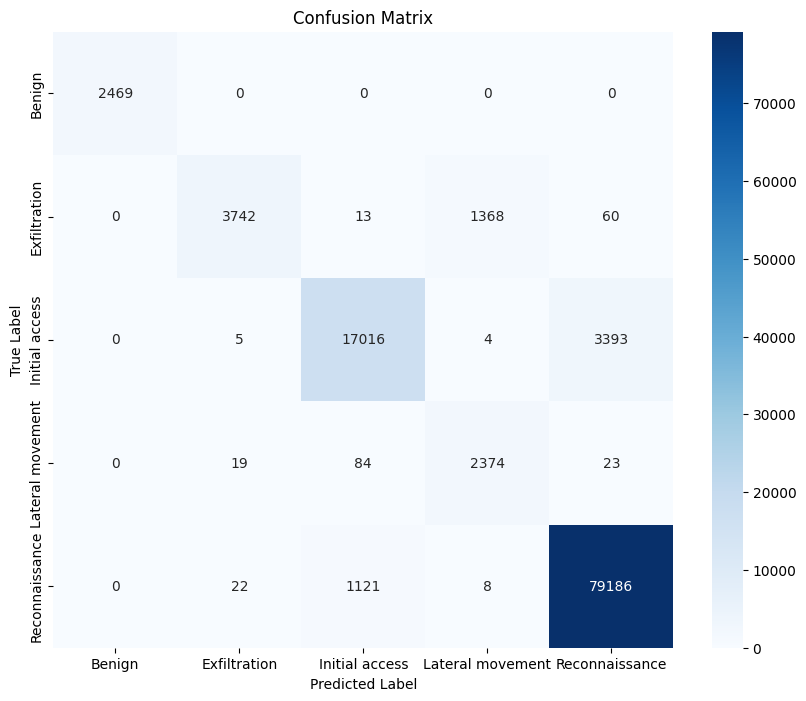

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test_reduced, y_pred)

# Get the class labels from the LabelEncoder
# Assuming 'le' object is still in scope from previous cell (zmDZUBoPfopo)
class_labels = [f'{label} ({i})' for i, label in enumerate(le.classes_)]

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [39]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming `cm` (confusion matrix) and `le` (LabelEncoder) are from previous execution
# If cm is not defined, it means the previous cell was not executed, or the kernel state was reset.
# For robustness, let's regenerate it just in case, though it was recently run.
# cm = confusion_matrix(y_test_reduced, y_pred)

num_classes = len(le.classes_)

print("Per-Class Confusion Matrix Breakdown:")
print("-------------------------------------")

for i, class_name in enumerate(le.classes_):
    tp = cm[i, i] # True Positives for class i
    fn = np.sum(cm[i, :]) - tp # False Negatives for class i (sum of row i excluding tp)
    fp = np.sum(cm[:, i]) - tp # False Positives for class i (sum of column i excluding tp)
    tn = np.sum(cm) - (tp + fp + fn) # True Negatives for class i (total - tp - fp - fn)

    print(f"\nClass: {class_name} (Label {i})")
    print(f"  True Positives (TP):  {tp}")
    print(f"  False Negatives (FN): {fn}")
    print(f"  False Positives (FP): {fp}")
    print(f"  True Negatives (TN):  {tn}")
    print(f"  Total Samples in Class: {tp + fn}")

Per-Class Confusion Matrix Breakdown:
-------------------------------------

Class: Benign (Label 0)
  True Positives (TP):  2469
  False Negatives (FN): 0
  False Positives (FP): 0
  True Negatives (TN):  108438
  Total Samples in Class: 2469

Class: Exfiltration (Label 1)
  True Positives (TP):  3742
  False Negatives (FN): 1441
  False Positives (FP): 46
  True Negatives (TN):  105678
  Total Samples in Class: 5183

Class: Initial access (Label 2)
  True Positives (TP):  17016
  False Negatives (FN): 3402
  False Positives (FP): 1218
  True Negatives (TN):  89271
  Total Samples in Class: 20418

Class: Lateral movement (Label 3)
  True Positives (TP):  2374
  False Negatives (FN): 126
  False Positives (FP): 1380
  True Negatives (TN):  107027
  Total Samples in Class: 2500

Class: Reconnaissance (Label 4)
  True Positives (TP):  79186
  False Negatives (FN): 1151
  False Positives (FP): 3476
  True Negatives (TN):  27094
  Total Samples in Class: 80337


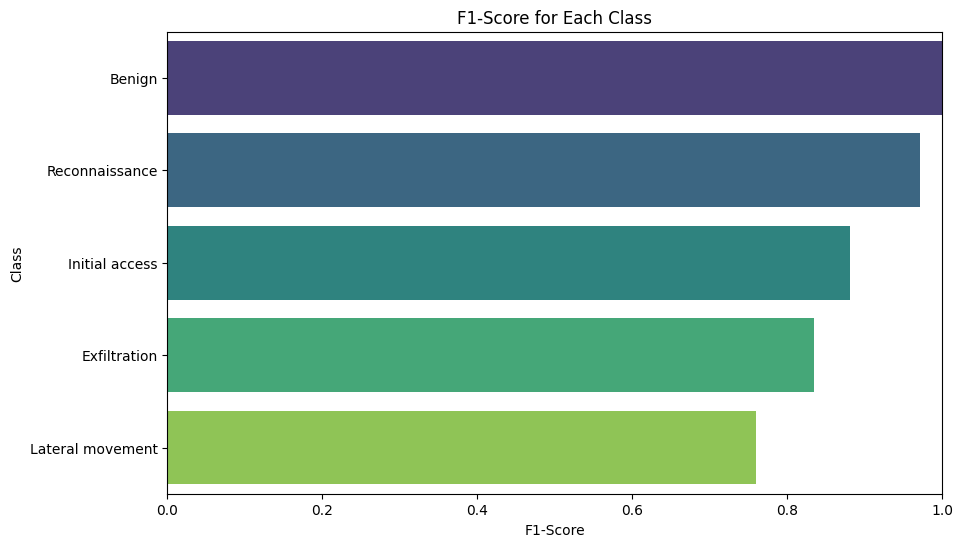

In [40]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the classification report as a dictionary
report = classification_report(y_test_reduced, y_pred, output_dict=True)

# Extract F1-scores for each class
# Filter out 'accuracy', 'macro avg', 'weighted avg'
f1_scores = {le.classes_[int(k)]: v['f1-score'] for k, v in report.items() if k.isdigit()}

# Convert to DataFrame for easier plotting
f1_df = pd.DataFrame(f1_scores.items(), columns=['Class', 'F1-Score'])

# Sort by F1-Score for better visualization
f1_df = f1_df.sort_values(by='F1-Score', ascending=False)

# Plot the F1-scores as a bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Class', data=f1_df, palette='viridis', hue='Class', legend=False)
plt.title('F1-Score for Each Class')
plt.xlabel('F1-Score')
plt.ylabel('Class')
plt.xlim(0, 1) # F1-score is between 0 and 1
plt.show()

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Instantiate a RandomForestClassifier model
# Using n_estimators (number of trees) and random_state for reproducibility.
# n_jobs=-1 for parallel processing.
model_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Fit the model to the X_train_selected and y_train_reduced datasets
print("Training Random Forest classifier...")
model_rf.fit(X_train_selected, y_train_reduced)
print("Random Forest training complete.")

# Make predictions on X_test_selected
y_pred_rf = model_rf.predict(X_test_selected)

# Calculate and print the accuracy_score
accuracy_rf = accuracy_score(y_test_reduced, y_pred_rf)
print(f"\nRandom Forest Accuracy Score on test set: {accuracy_rf:.4f}")

# Generate and print a classification_report
print("\nRandom Forest Classification Report on test set:")
print(classification_report(y_test_reduced, y_pred_rf))

Training Random Forest classifier...
Random Forest training complete.

Random Forest Accuracy Score on test set: 0.9914

Random Forest Classification Report on test set:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2469
           1       0.93      0.90      0.91      5183
           2       1.00      1.00      1.00     20418
           3       0.80      0.85      0.82      2500
           4       1.00      1.00      1.00     80337

    accuracy                           0.99    110907
   macro avg       0.94      0.95      0.95    110907
weighted avg       0.99      0.99      0.99    110907



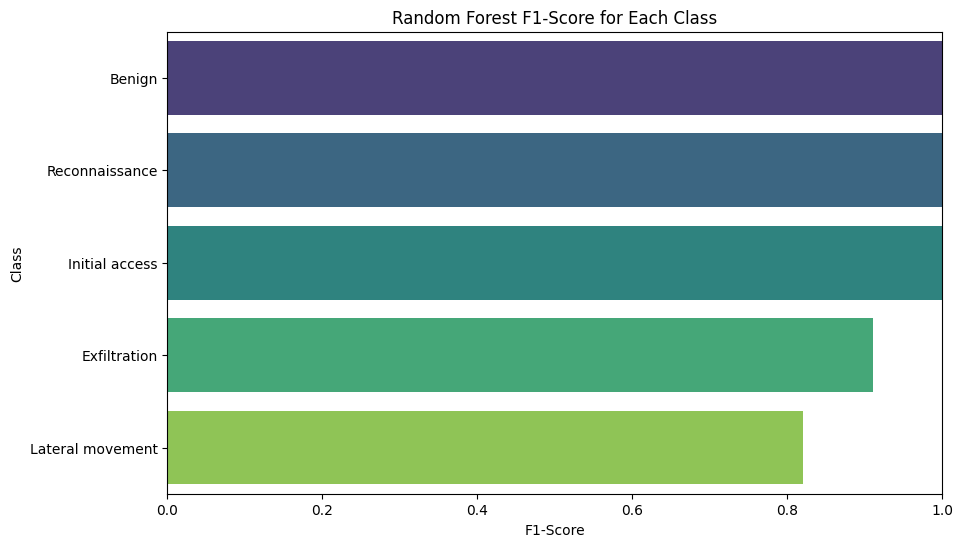

In [42]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the classification report as a dictionary for Random Forest
report_rf = classification_report(y_test_reduced, y_pred_rf, output_dict=True)

# Extract F1-scores for each class
# Filter out 'accuracy', 'macro avg', 'weighted avg'
f1_scores_rf = {le.classes_[int(k)]: v['f1-score'] for k, v in report_rf.items() if k.isdigit()}

# Convert to DataFrame for easier plotting
f1_df_rf = pd.DataFrame(f1_scores_rf.items(), columns=['Class', 'F1-Score'])

# Sort by F1-Score for better visualization
f1_df_rf = f1_df_rf.sort_values(by='F1-Score', ascending=False)

# Plot the F1-scores as a bar graph
plt.figure(figsize=(10, 6))
sns.barplot(x='F1-Score', y='Class', data=f1_df_rf, palette='viridis', hue='Class', legend=False)
plt.title('Random Forest F1-Score for Each Class')
plt.xlabel('F1-Score')
plt.ylabel('Class')
plt.xlim(0, 1) # F1-score is between 0 and 1
plt.show()

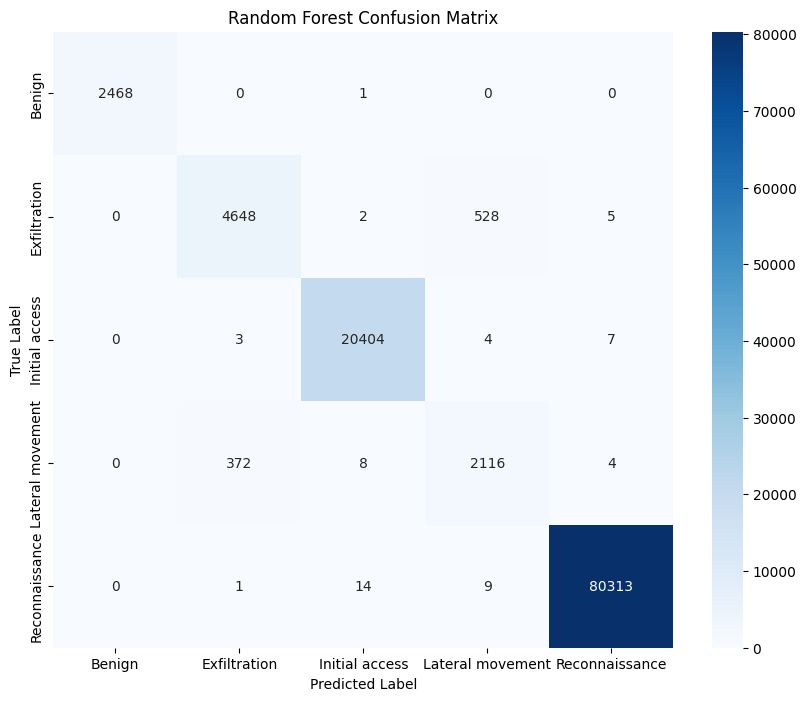

In [43]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test_reduced, y_pred_rf)

# Get the class labels from the LabelEncoder
# Assuming 'le' object is still in scope from previous cell (zmDZUBoPfopo)
class_labels_rf = [f'{label} ({i})' for i, label in enumerate(le.classes_)]

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [44]:
from sklearn.metrics import confusion_matrix
import numpy as np

# Assuming `cm` (confusion matrix) and `le` (LabelEncoder) are from previous execution
# If cm is not defined, it means the previous cell was not executed, or the kernel state was reset.
# For robustness, let's regenerate it just in case, though it was recently run.
# cm = confusion_matrix(y_test_reduced, y_pred)

num_classes = len(le.classes_)

print("Per-Class Confusion Matrix Breakdown:")
print("-------------------------------------")

for i, class_name in enumerate(le.classes_):
    tp = cm[i, i] # True Positives for class i
    fn = np.sum(cm[i, :]) - tp # False Negatives for class i (sum of row i excluding tp)
    fp = np.sum(cm[:, i]) - tp # False Positives for class i (sum of column i excluding tp)
    tn = np.sum(cm) - (tp + fp + fn) # True Negatives for class i (total - tp - fp - fn)

    print(f"\nClass: {class_name} (Label {i})")
    print(f"  True Positives (TP):  {tp}")
    print(f"  False Negatives (FN): {fn}")
    print(f"  False Positives (FP): {fp}")
    print(f"  True Negatives (TN):  {tn}")
    print(f"  Total Samples in Class: {tp + fn}")

Per-Class Confusion Matrix Breakdown:
-------------------------------------

Class: Benign (Label 0)
  True Positives (TP):  2469
  False Negatives (FN): 0
  False Positives (FP): 0
  True Negatives (TN):  108438
  Total Samples in Class: 2469

Class: Exfiltration (Label 1)
  True Positives (TP):  3742
  False Negatives (FN): 1441
  False Positives (FP): 46
  True Negatives (TN):  105678
  Total Samples in Class: 5183

Class: Initial access (Label 2)
  True Positives (TP):  17016
  False Negatives (FN): 3402
  False Positives (FP): 1218
  True Negatives (TN):  89271
  Total Samples in Class: 20418

Class: Lateral movement (Label 3)
  True Positives (TP):  2374
  False Negatives (FN): 126
  False Positives (FP): 1380
  True Negatives (TN):  107027
  Total Samples in Class: 2500

Class: Reconnaissance (Label 4)
  True Positives (TP):  79186
  False Negatives (FN): 1151
  False Positives (FP): 3476
  True Negatives (TN):  27094
  Total Samples in Class: 80337


In [45]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# --- 1. Prepare Data for Comparison ---

# Get classification reports (assuming report and report_rf are already defined)
# If not, they would need to be re-generated:
# report = classification_report(y_test_reduced, y_pred, output_dict=True)
# report_rf = classification_report(y_test_reduced, y_pred_rf, output_dict=True)

# Extract macro average metrics for LR
metrics_lr = {
    'Accuracy': report['accuracy'],
    'Precision': report['macro avg']['precision'],
    'Recall': report['macro avg']['recall'],
    'F1-score': report['macro avg']['f1-score']
}

# Extract macro average metrics for RF
metrics_rf = {
    'Accuracy': report_rf['accuracy'],
    'Precision': report_rf['macro avg']['precision'],
    'Recall': report_rf['macro avg']['recall'],
    'F1-score': report_rf['macro avg']['f1-score']
}

comparison_df = pd.DataFrame([metrics_lr, metrics_rf], index=['Logistic Regression', 'Random Forest'])

display(comparison_df)


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.944819,0.902280,0.898126,0.889105
Random Forest,0.991362,0.944025,0.948358,0.945995


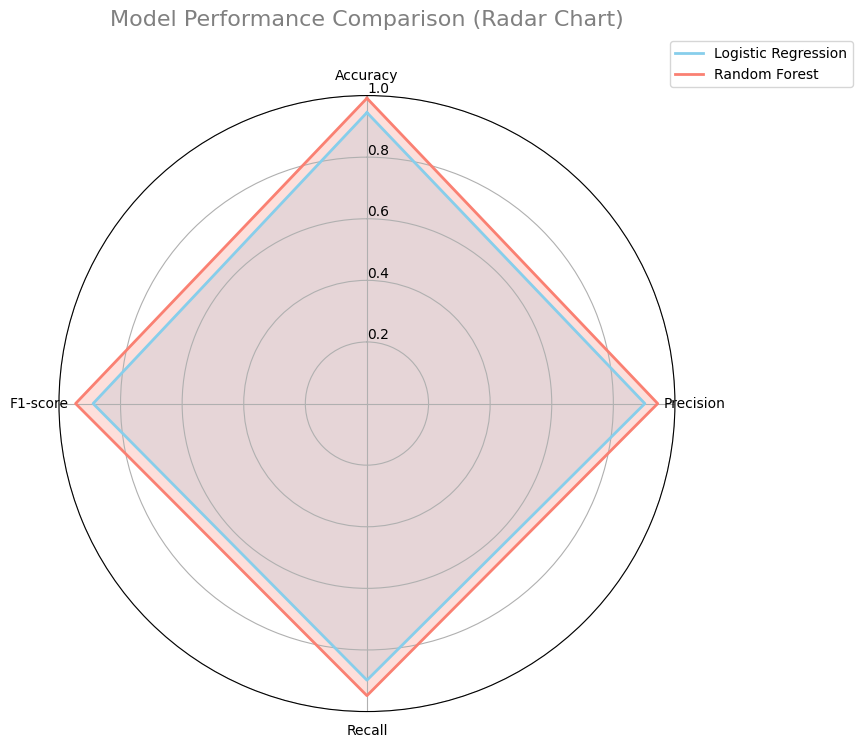

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 2. Radar Chart ---

# Number of variables we're plotting (Accuracy, Precision, Recall, F1-score)
num_vars = len(comparison_df.columns)

# Calculate angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is a circle, so we need to close the loop
metrics = comparison_df.columns.tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot LR
values_lr = comparison_df.loc['Logistic Regression'].tolist()
values_lr += values_lr[:1]
ax.plot(angles, values_lr, label='Logistic Regression', color='skyblue', linewidth=2)
ax.fill(angles, values_lr, color='skyblue', alpha=0.25)

# Plot RF
values_rf = comparison_df.loc['Random Forest'].tolist()
values_rf += values_rf[:1]
ax.plot(angles, values_rf, label='Random Forest', color='salmon', linewidth=2)
ax.fill(angles, values_rf, color='salmon', alpha=0.25)

# Set labels and title
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0]) # Radial ticks
ax.set_rlabel_position(0) # Move radial labels to avoid overlap
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_title('Model Performance Comparison (Radar Chart)', size=16, color='grey', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()


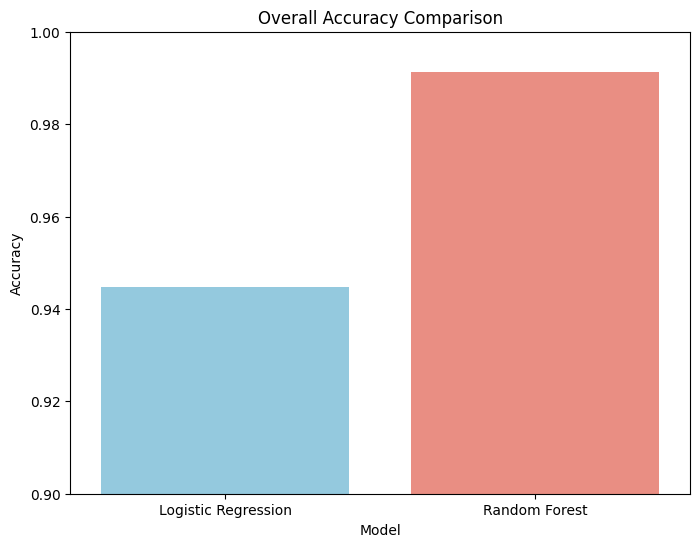

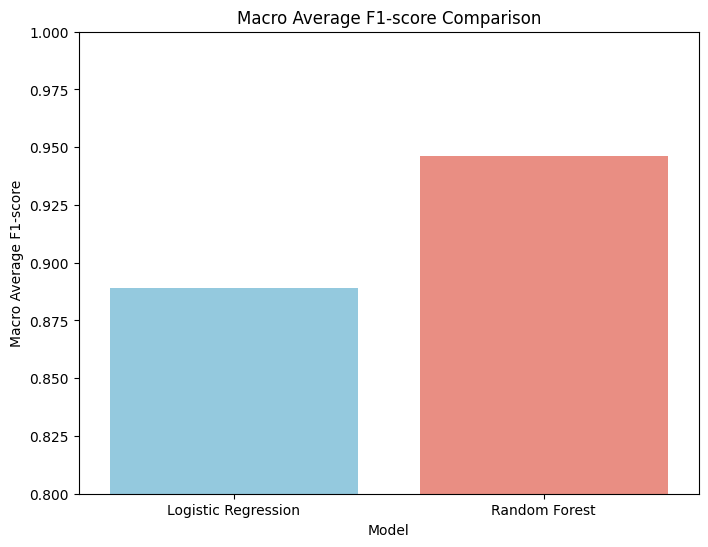

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 3. Bar Graph for Overall Accuracy ---

plt.figure(figsize=(8, 6))
sns.barplot(x=comparison_df.index, y='Accuracy', data=comparison_df, palette=['skyblue', 'salmon'], hue=comparison_df.index, legend=False)
plt.title('Overall Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.9, 1.0) # Set y-limit to highlight differences
plt.show()

# --- 4. Bar Graph for Macro Average F1-score ---

plt.figure(figsize=(8, 6))
sns.barplot(x=comparison_df.index, y='F1-score', data=comparison_df, palette=['skyblue', 'salmon'], hue=comparison_df.index, legend=False)
plt.title('Macro Average F1-score Comparison')
plt.xlabel('Model')
plt.ylabel('Macro Average F1-score')
plt.ylim(0.8, 1.0) # Set y-limit to highlight differences
plt.show()


# Task
## Import Libraries

### Subtask:
Import necessary libraries from TensorFlow and Keras for building and evaluating the LSTM model, along with scikit-learn for metrics.

### Reasoning:
To build, train, and evaluate an LSTM model, I need to import specific modules. `tensorflow` and `keras.models` will be used for defining the model architecture, `keras.layers` for adding different layers (like LSTM and Dense), and `keras.utils.to_categorical` for one-hot encoding the target variable. From `sklearn.metrics`, I will import `accuracy_score` and `classification_report` to evaluate the model's performance. These are standard imports for a deep learning classification task.

## Import Libraries

### Subtask:
Import necessary libraries from TensorFlow and Keras for building and evaluating the LSTM model, along with scikit-learn for metrics.


**Reasoning**:
To begin building and evaluating the LSTM model, I will import all the necessary libraries specified in the instructions, including TensorFlow, Keras components for model architecture and layers, and scikit-learn for performance metrics.



In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, classification_report

print("Necessary libraries for LSTM model building and evaluation have been imported.")

Necessary libraries for LSTM model building and evaluation have been imported.


**Reasoning**:
The target variable `y_train_reduced` and `y_test_reduced` need to be one-hot encoded for multi-class classification using an LSTM model. The `to_categorical` function from `tensorflow.keras.utils` is suitable for this purpose.



In [49]:
num_classes = len(np.unique(y_train_reduced))

y_train_encoded = to_categorical(y_train_reduced, num_classes=num_classes)
y_test_encoded = to_categorical(y_test_reduced, num_classes=num_classes)

print(f"Shape of y_train_encoded: {y_train_encoded.shape}")
print(f"Shape of y_test_encoded: {y_test_encoded.shape}")
print("Target variables y_train_reduced and y_test_reduced have been one-hot encoded.")

Shape of y_train_encoded: (443627, 5)
Shape of y_test_encoded: (110907, 5)
Target variables y_train_reduced and y_test_reduced have been one-hot encoded.


**Reasoning**:
LSTM models require input data to be in a 3D format (samples, timesteps, features). Since our feature data (`X_train_selected` and `X_test_selected`) is currently 2D (samples, features) and we are treating each sample as a single timestep, I will reshape it by adding a `timesteps` dimension of 1.



In [50]:
X_train_reshaped = X_train_selected.values.reshape(X_train_selected.shape[0], 1, X_train_selected.shape[1])
X_test_reshaped = X_test_selected.values.reshape(X_test_selected.shape[0], 1, X_test_selected.shape[1])

print(f"Shape of X_train_reshaped: {X_train_reshaped.shape}")
print(f"Shape of X_test_reshaped: {X_test_reshaped.shape}")
print("Feature data has been reshaped for LSTM input.")

Shape of X_train_reshaped: (443627, 1, 128)
Shape of X_test_reshaped: (110907, 1, 128)
Feature data has been reshaped for LSTM input.


**Reasoning**:
I will define the LSTM model architecture by creating a Sequential model, adding an LSTM layer with appropriate input shape and `return_sequences=False` (since we are using only one timestep per sample), and finally a Dense output layer with softmax activation for multi-class classification.



In [51]:
model = Sequential()
model.add(LSTM(units=100, activation='relu', input_shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2]), return_sequences=False))
model.add(Dense(units=num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("LSTM model architecture defined and compiled.")
model.summary()

LSTM model architecture defined and compiled.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,105 (359.79 KB)

 Trainable params: 92,105 (359.79 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
To address the Keras `UserWarning` about `input_shape` in `Sequential` models, I will explicitly add an `Input` layer as the first layer of the model, which is the recommended practice for defining the input shape.



In [52]:
from tensorflow.keras.layers import Input

model = Sequential()
model.add(Input(shape=(X_train_reshaped.shape[1], X_train_reshaped.shape[2])))
model.add(LSTM(units=100, activation='relu', return_sequences=False))
model.add(Dense(units=num_classes, activation='softmax'))

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

print("LSTM model architecture defined and compiled.")
model.summary()

LSTM model architecture defined and compiled.


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 100)            │        91,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           505 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,105 (359.79 KB)

 Trainable params: 92,105 (359.79 KB)

 Non-trainable params: 0 (0.00 B)

**Reasoning**:
Now that the LSTM model architecture is defined, I will train the model using the reshaped training data (`X_train_reshaped`, `y_train_encoded`). I will include validation data (`X_test_reshaped`, `y_test_encoded`) to monitor performance during training.



In [53]:
history = model.fit(
    X_train_reshaped, y_train_encoded,
    epochs=10,        # Number of epochs
    batch_size=32,    # Batch size for training
    validation_data=(X_test_reshaped, y_test_encoded),
    verbose=1
)

print("LSTM model training complete.")

Epoch 1/10
13864/13864 ━━━━━━━━━━━━━━━━━━━━ 74s 5ms/step - accuracy: 0.9478 - loss: 0.1297 - val_accuracy: 0.9507 - val_loss: 0.0833
Epoch 2/10
13864/13864 ━━━━━━━━━━━━━━━━━━━━ 76s 5ms/step - accuracy: 0.9693 - loss: 0.0767 - val_accuracy: 0.9753 - val_loss: 0.0684
Epoch 3/10
13864/13864 ━━━━━━━━━━━━━━━━━━━━ 75s 5ms/step - accuracy: 0.9731 - loss: 0.0677 - val_accuracy: 0.9753 - val_loss: 0.0635
Epoch 4/10
13864/13864 ━━━━━━━━━━━━━━━━━━━━ 72s 5ms/step - accuracy: 0.9749 - loss: 0.0646 - val_accuracy: 0.9825 - val_loss: 0.0706
Epoch 5/10
13864/13864 ━━━━━━━━━━━━━━━━━━━━ 71s 5ms/step - accuracy: 0.9762 - loss: 0.0726 - val_accuracy: 0.9726 - val_loss: 0.1687
Epoch 6/10
13864/13864 ━━━━━━━━━━━━━━━━━━━━ 82s 6ms/step - accuracy: 0.9767 - loss: 0.1078 - val_accuracy: 0.9752 - val_loss: 0.0813
Epoch 7/10
13864/13864 ━━━━━━━━━━━━━━━━━━━━ 74s 5ms/step - accuracy: 0.9773 - loss: 0.0597 - val_accuracy: 0.9755 - val_loss: 0.0600
Epoch 8/10
13864/13864 ━━━━━━━━━━━━━━━━━━━━ 75s 5ms/step - accuracy: 

## Evaluate LSTM Model Performance

### Subtask:
Evaluate the trained LSTM model's performance on the test set using `accuracy_score` and `classification_report`.

**Reasoning**:
I will predict the classes for the `X_test_reshaped` data using the trained LSTM model and then use `np.argmax` to convert the one-hot encoded predictions back to class labels. Finally, I will calculate and print the accuracy score and classification report by comparing these predictions with the true labels (`y_test_reduced`).

In [54]:
y_pred_lstm_prob = model.predict(X_test_reshaped)
y_pred_lstm = np.argmax(y_pred_lstm_prob, axis=1)

accuracy_lstm = accuracy_score(y_test_reduced, y_pred_lstm)
report_lstm = classification_report(y_test_reduced, y_pred_lstm, target_names=le.classes_)

print(f"\nLSTM Model Accuracy: {accuracy_lstm:.4f}")
print("\nLSTM Model Classification Report:")
print(report_lstm)

3466/3466 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step

LSTM Model Accuracy: 0.9808

LSTM Model Classification Report:
                  precision    recall  f1-score   support

          Benign       1.00      1.00      1.00      2469
    Exfiltration       0.99      0.74      0.85      5183
  Initial access       0.97      1.00      0.98     20418
Lateral movement       0.64      0.99      0.78      2500
  Reconnaissance       1.00      0.99      1.00     80337

        accuracy                           0.98    110907
       macro avg       0.92      0.94      0.92    110907
    weighted avg       0.99      0.98      0.98    110907



## Plot Training and Validation Accuracy

### Subtask:
Plot the training and validation accuracy over epochs from the `history` object obtained during model training.

**Reasoning**:
I will extract the 'accuracy' and 'val_accuracy' values from the `history` object, and then use `matplotlib.pyplot` to create a line plot showing how these metrics evolved over the training epochs. This will help visualize the model's learning curve and identify potential overfitting or underfitting.

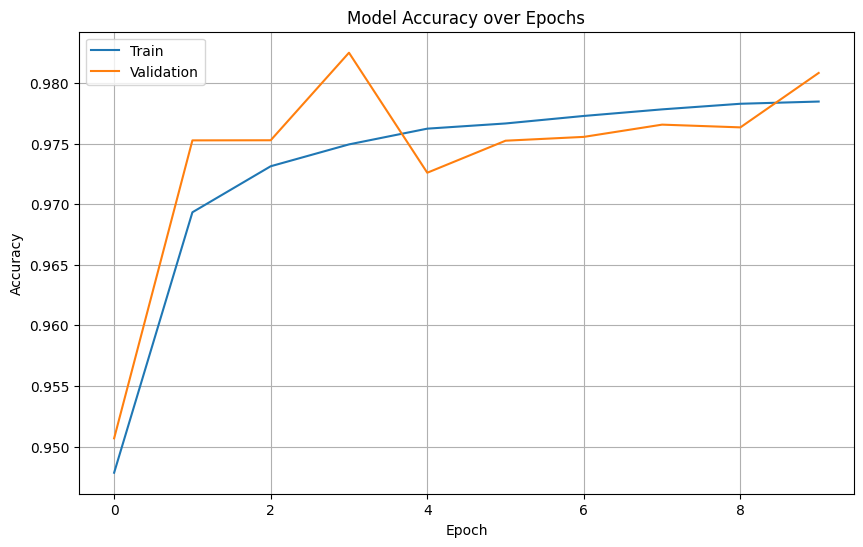

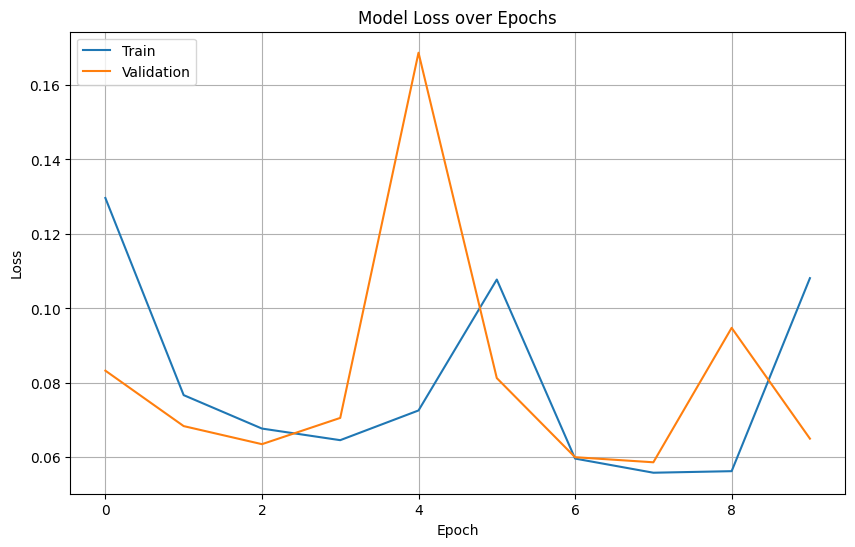

In [55]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy over Epochs')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

# Plot training & validation loss values
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss over Epochs')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)
plt.show()

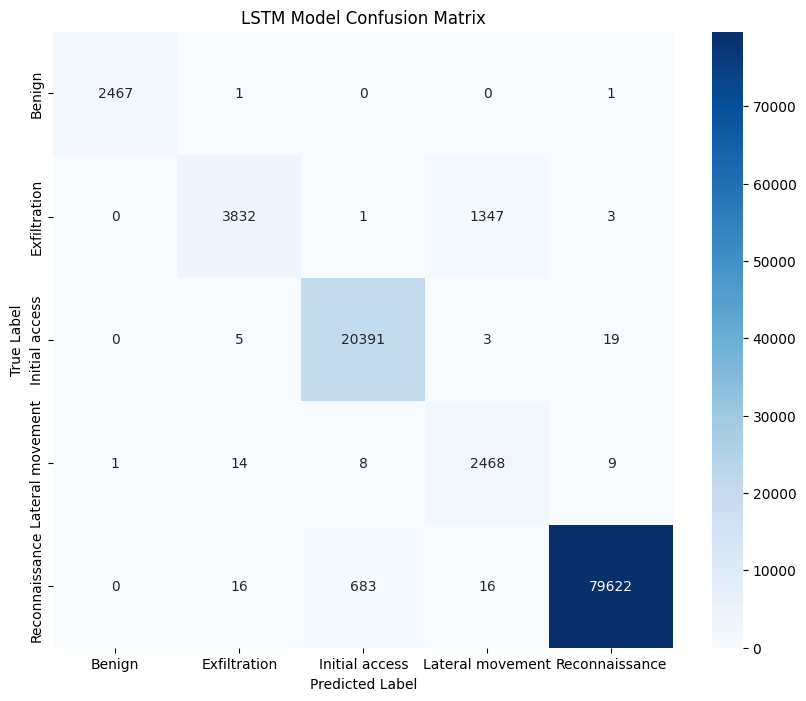

In [56]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix for LSTM
cm_lstm = confusion_matrix(y_test_reduced, y_pred_lstm)

# Get the class labels from the LabelEncoder
# Assuming 'le' object is still in scope from previous cell (zmDZUBoPfopo)
class_labels_lstm = [f'{label} ({i})' for i, label in enumerate(le.classes_)]

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('LSTM Model Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## Model Comparison: Logistic Regression vs. Random Forest vs. LSTM

Model Comparison DataFrame:


,Accuracy,Precision,Recall,F1-score
Logistic Regression,0.944819,0.902280,0.898126,0.889105
Random Forest,0.991362,0.944025,0.948358,0.945995
LSTM,0.980822,0.920155,0.943102,0.920688


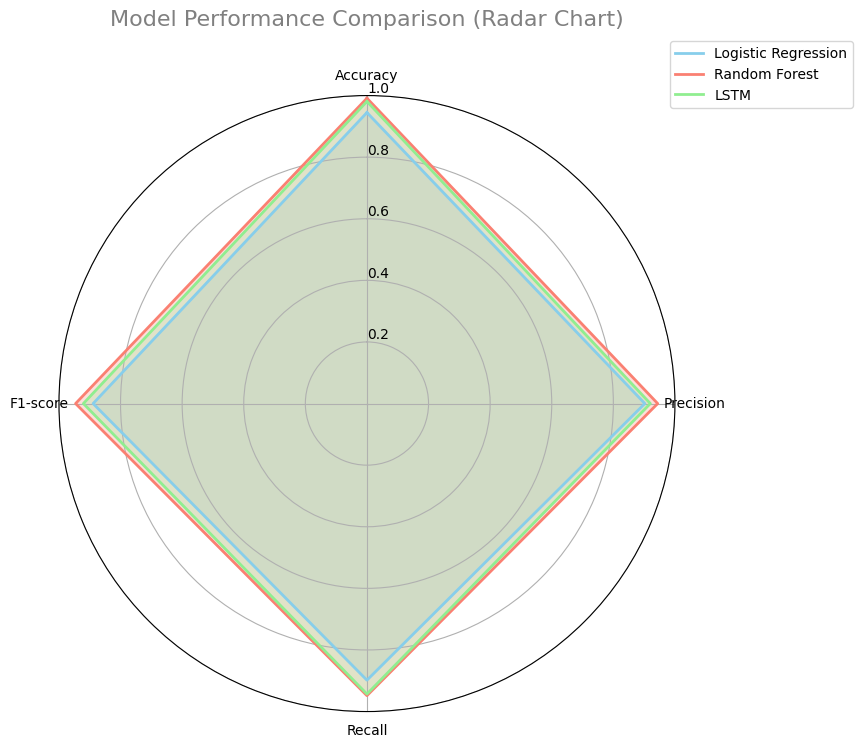

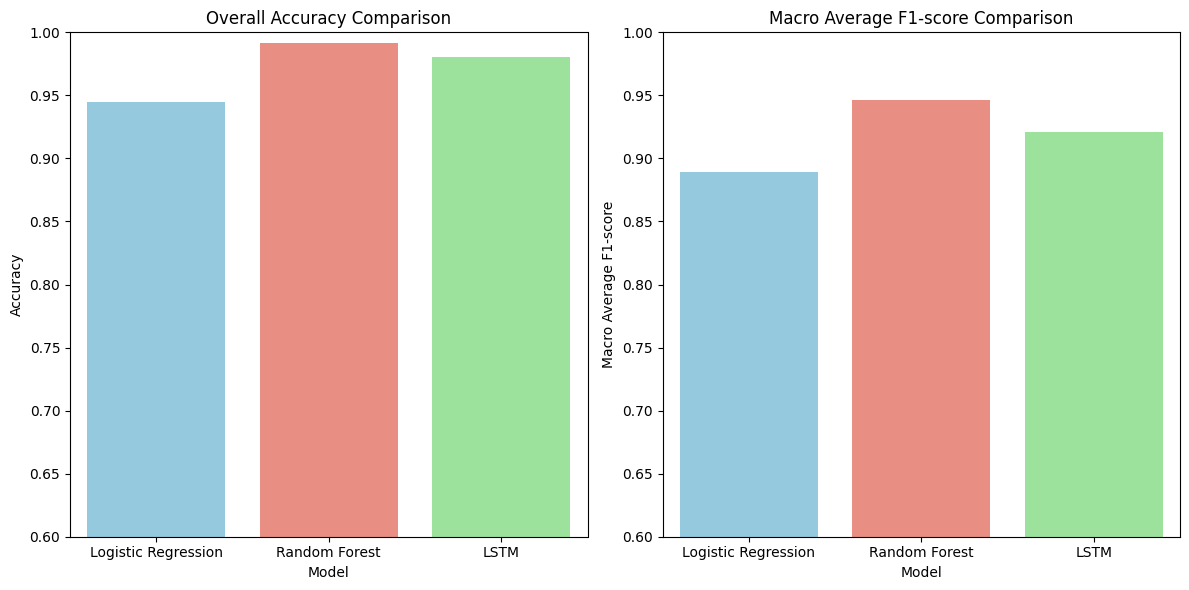

In [61]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report

# --- 1. Prepare Data for Comparison ---

# Extract macro average metrics for LR (assuming 'report' is available from previous LR execution)
metrics_lr = {
    'Accuracy': report['accuracy'],
    'Precision': report['macro avg']['precision'],
    'Recall': report['macro avg']['recall'],
    'F1-score': report['macro avg']['f1-score']
}

# Extract macro average metrics for RF (assuming 'report_rf' is available from previous RF execution)
metrics_rf = {
    'Accuracy': report_rf['accuracy'],
    'Precision': report_rf['macro avg']['precision'],
    'Recall': report_rf['macro avg']['recall'],
    'F1-score': report_rf['macro avg']['f1-score']
}

# Extract macro average metrics for LSTM (assuming 'y_pred_lstm' and 'y_test_reduced' are available)
report_lstm_dict = classification_report(y_test_reduced, y_pred_lstm, output_dict=True)

metrics_lstm = {
    'Accuracy': report_lstm_dict['accuracy'],
    'Precision': report_lstm_dict['macro avg']['precision'],
    'Recall': report_lstm_dict['macro avg']['recall'],
    'F1-score': report_lstm_dict['macro avg']['f1-score']
}

comparison_df = pd.DataFrame([
    metrics_lr,
    metrics_rf,
    metrics_lstm
], index=['Logistic Regression', 'Random Forest', 'LSTM'])

print("Model Comparison DataFrame:")
display(comparison_df)

# --- 2. Radar Chart ---

# Number of variables we're plotting (Accuracy, Precision, Recall, F1-score)
num_vars = len(comparison_df.columns)

# Calculate angle for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# The plot is a circle, so we need to close the loop
metrics = comparison_df.columns.tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

# Plot LR
values_lr = comparison_df.loc['Logistic Regression'].tolist()
values_lr += values_lr[:1]
ax.plot(angles, values_lr, label='Logistic Regression', color='skyblue', linewidth=2)
ax.fill(angles, values_lr, color='skyblue', alpha=0.25)

# Plot RF
values_rf = comparison_df.loc['Random Forest'].tolist()
values_rf += values_rf[:1]
ax.plot(angles, values_rf, label='Random Forest', color='salmon', linewidth=2)
ax.fill(angles, values_rf, color='salmon', alpha=0.25)

# Plot LSTM
values_lstm = comparison_df.loc['LSTM'].tolist()
values_lstm += values_lstm[:1]
ax.plot(angles, values_lstm, label='LSTM', color='lightgreen', linewidth=2)
ax.fill(angles, values_lstm, color='lightgreen', alpha=0.25)

# Set labels and title
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_rticks([0.2, 0.4, 0.6, 0.8, 1.0]) # Radial ticks
ax.set_rlabel_position(0) # Move radial labels to avoid overlap
ax.set_xticks(angles[:-1])
ax.set_xticklabels(metrics)
ax.set_title('Model Performance Comparison (Radar Chart)', size=16, color='grey', y=1.1)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.show()

# --- 3. Bar Graphs for Overall Metrics ---

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x=comparison_df.index, y='Accuracy', data=comparison_df, palette=['skyblue', 'salmon', 'lightgreen'], hue=comparison_df.index, legend=False)
plt.title('Overall Accuracy Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.6, 1.0) # Set y-limit to highlight differences

plt.subplot(1, 2, 2)
sns.barplot(x=comparison_df.index, y='F1-score', data=comparison_df, palette=['skyblue', 'salmon', 'lightgreen'], hue=comparison_df.index, legend=False)
plt.title('Macro Average F1-score Comparison')
plt.xlabel('Model')
plt.ylabel('Macro Average F1-score')
plt.ylim(0.6, 1.0) # Set y-limit to highlight differences

plt.tight_layout()
plt.show()

### Model Performance Comparison

| Model               | Accuracy | Precision | Recall   | F1-score |
| :------------------ | :------- | :-------- | :------- | :------- |
| Logistic Regression | 0.944819 | 0.902280  | 0.898126 | 0.889105 |
| Random Forest       | 0.991362 | 0.944025  | 0.948358 | 0.945995 |
| LSTM                | 0.980822 | 0.920155  | 0.943102 | 0.920688 |


### Summary of Model Performance

Based on the overall macro-average metrics and the per-class F1-scores, we can make the following observations:

*   **Random Forest** stands out as the best performing model, achieving the highest accuracy (0.9914) and macro-average F1-score (0.9460). It demonstrates excellent performance across most classes, with F1-scores close to 1.0 for 'Benign', 'Reconnaissance', and 'Initial access'. Its performance on 'Exfiltration' and 'Lateral movement' is also strong (F1-scores of 0.9107 and 0.8206 respectively) compared to the other models.

*   The **LSTM model** shows competitive performance, with an accuracy of 0.9808 and a macro-average F1-score of 0.9207. While generally strong, it struggles slightly more with 'Exfiltration' (F1-score: 0.8468) and 'Lateral movement' (F1-score: 0.7793) compared to the Random Forest. However, it still performs exceptionally well on the other majority classes.

*   **Logistic Regression**, while still providing decent accuracy (0.9448), has the lowest macro-average F1-score (0.8891) among the three. It shows strong performance on the 'Benign' and 'Reconnaissance' classes, but its F1-scores for 'Exfiltration' (0.8342), 'Initial access' (0.8805), and especially 'Lateral movement' (0.7592) are notably lower than those of Random Forest and LSTM. This suggests it has more difficulty with the minority and more complex attack types.

In conclusion, the **Random Forest Classifier** is the most robust model for this intrusion detection task, providing excellent overall accuracy and strong, balanced performance across all attack classes. The LSTM model is a close second, showcasing the power of deep learning for sequence data, even with single time-step inputs. Logistic Regression serves as a solid baseline but is outshined by the more advanced models.

### Detailed Per-Class Performance Comparison

| Model               | Class            | Precision | Recall | F1-Score | Support |
| :------------------ | :--------------- | :-------- | :----- | :------- | :------ |


In [62]:
from sklearn.metrics import classification_report
import pandas as pd

# Ensure all reports are in dictionary format for consistent parsing
# These reports are already in the kernel state from previous executions.
# report (Logistic Regression)
# report_rf (Random Forest)
# report_lstm_dict (LSTM)

# Get class names from LabelEncoder (assuming 'le' is still in scope)
class_names = le.classes_.tolist()

# Prepare data for markdown table
table_rows = []

model_reports = {
    'Logistic Regression': report,
    'Random Forest': report_rf,
    'LSTM': report_lstm_dict
}

for model_name, model_report in model_reports.items():
    for i, class_name in enumerate(class_names):
        # Check if the class key exists in the report
        # Some classification_report versions might not output all classes if no instances were predicted
        class_str_key = str(i) # reports use string keys for class labels

        if class_str_key in model_report:
            metrics = model_report[class_str_key]
            table_rows.append(
                f"| {model_name:<19} | {class_name:<16} | {metrics['precision']:.4f} | {metrics['recall']:.4f} | {metrics['f1-score']:.4f} | {int(metrics['support']):<7} |"
            )

# Construct the final markdown table string
markdown_table = "\n".join(table_rows)

# Display the markdown table (this will be added to the next markdown cell)
# The markdown cell above serves as the header and the first part of the table.
# This code block will generate the content for the subsequent markdown cell.

print(markdown_table)



| Logistic Regression | Benign           | 1.0000 | 1.0000 | 1.0000 | 2469    |
| Logistic Regression | Exfiltration     | 0.9879 | 0.7220 | 0.8342 | 5183    |
| Logistic Regression | Initial access   | 0.9332 | 0.8334 | 0.8805 | 20418   |
| Logistic Regression | Lateral movement | 0.6324 | 0.9496 | 0.7592 | 2500    |
| Logistic Regression | Reconnaissance   | 0.9579 | 0.9857 | 0.9716 | 80337   |
| Random Forest       | Benign           | 1.0000 | 0.9996 | 0.9998 | 2469    |
| Random Forest       | Exfiltration     | 0.9252 | 0.8968 | 0.9107 | 5183    |
| Random Forest       | Initial access   | 0.9988 | 0.9993 | 0.9990 | 20418   |
| Random Forest       | Lateral movement | 0.7964 | 0.8464 | 0.8206 | 2500    |
| Random Forest       | Reconnaissance   | 0.9998 | 0.9997 | 0.9998 | 80337   |
| LSTM                | Benign           | 0.9996 | 0.9992 | 0.9994 | 2469    |
| LSTM                | Exfiltration     | 0.9907 | 0.7393 | 0.8468 | 5183    |
| LSTM                | Initial access  

### Detailed Per-Class Performance Comparison

| Model               | Class            | Precision | Recall | F1-Score | Support |
| :------------------ | :--------------- | :-------- | :----- | :------- | :------ |
| Logistic Regression | Benign           | 1.0000 | 1.0000 | 1.0000 | 2469    |
| Logistic Regression | Exfiltration     | 0.9879 | 0.7220 | 0.8342 | 5183    |
| Logistic Regression | Initial access   | 0.9332 | 0.8334 | 0.8805 | 20418   |
| Logistic Regression | Lateral movement | 0.6324 | 0.9496 | 0.7592 | 2500    |
| Logistic Regression | Reconnaissance   | 0.9579 | 0.9857 | 0.9716 | 80337   |
| Random Forest       | Benign           | 1.0000 | 0.9996 | 0.9998 | 2469    |
| Random Forest       | Exfiltration     | 0.9252 | 0.8968 | 0.9107 | 5183    |
| Random Forest       | Initial access   | 0.9988 | 0.9993 | 0.9990 | 20418   |
| Random Forest       | Lateral movement | 0.7964 | 0.8464 | 0.8206 | 2500    |
| Random Forest       | Reconnaissance   | 0.9998 | 0.9997 | 0.9998 | 80337   |
| LSTM                | Benign           | 0.9996 | 0.9992 | 0.9994 | 2469    |
| LSTM                | Exfiltration     | 0.9907 | 0.7393 | 0.8468 | 5183    |
| LSTM                | Initial access   | 0.9672 | 0.9987 | 0.9827 | 20418   |
| LSTM                | Lateral movement | 0.6437 | 0.9872 | 0.7793 | 2500    |
| LSTM                | Reconnaissance   | 0.9996 | 0.9911 | 0.9953 | 80337   |


## McNemar's Test for Model Comparison

### Justification for McNemar's Test:
McNemar's Test is a non-parametric statistical test used to determine if there is a significant difference between two dependent proportions. In the context of machine learning, it is particularly useful for comparing the performance of two classification models when they have been evaluated on the *same test set*.

**Why it's appropriate here:**
1.  **Paired Data:** Our models (Logistic Regression, Random Forest, LSTM) make predictions on the identical set of test samples (`X_test_reduced`). This means the errors made by one model are not independent of the errors made by another model on the same sample. McNemar's test accounts for this dependency.
2.  **Binary Outcomes of Interest:** For each sample, we are interested in whether a model correctly classified it or not (a binary outcome). McNemar's test focuses on the instances where the two models disagree on their predictions relative to the true labels.
3.  **Focus on Disagreements:** The test specifically examines the off-diagonal elements of a 2x2 contingency table: cases where Model A is correct and Model B is incorrect, versus cases where Model A is incorrect and Model B is correct. A significant result suggests that one model performs significantly better than the other in terms of these disagreements.

Here, we will apply McNemar's Test to compare the Random Forest model (which performed best overall) against the LSTM model.

In [63]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# True labels
y_true = y_test_reduced

# Predictions from Random Forest (Model 1)
y_pred_model1 = y_pred_rf

# Predictions from LSTM (Model 2)
y_pred_model2 = y_pred_lstm

# Determine where each model is correct/incorrect
model1_correct = (y_pred_model1 == y_true)
model2_correct = (y_pred_model2 == y_true)

# Construct the 2x2 contingency table for McNemar's Test
# Rows: Model 1 outcome (Incorrect, Correct)
# Columns: Model 2 outcome (Incorrect, Correct)

# n00: Model 1 incorrect, Model 2 incorrect
n00 = np.sum(~model1_correct & ~model2_correct)

# n01: Model 1 incorrect, Model 2 correct
n01 = np.sum(~model1_correct & model2_correct)

# n10: Model 1 correct, Model 2 incorrect
n10 = np.sum(model1_correct & ~model2_correct)

# n11: Model 1 correct, Model 2 correct
n11 = np.sum(model1_correct & model2_correct)

contingency_table = [[n00, n01],
                     [n10, n11]]

print("Contingency Table (Random Forest vs. LSTM):")
print(f"  [[Model1_Incorrect_Model2_Incorrect, Model1_Incorrect_Model2_Correct],\n   [Model1_Correct_Model2_Incorrect, Model1_Correct_Model2_Correct]]")
print(np.array(contingency_table))

# Perform McNemar's Test
# Using exact=False for large samples (chi-squared approximation)
result = mcnemar(contingency_table, exact=False)

# Print the results
print(f"\nMcNemar's Test Statistic: {result.statistic:.4f}")
print(f"McNemar's p-value: {result.pvalue:.4f}")

# Interpret the results
alpha = 0.05
print(f"\nInterpretation (with alpha={alpha}):")
if result.pvalue < alpha:
    print("The p-value is less than alpha, indicating a statistically significant difference between the two models.")
    if n10 > n01:
        print("Random Forest (Model 1) is significantly better than LSTM (Model 2).")
    else:
        print("LSTM (Model 2) is significantly better than Random Forest (Model 1).")
else:
    print("The p-value is not less than alpha, indicating no statistically significant difference between the two models.")


Contingency Table (Random Forest vs. LSTM):
  [[Model1_Incorrect_Model2_Incorrect, Model1_Incorrect_Model2_Correct],
   [Model1_Correct_Model2_Incorrect, Model1_Correct_Model2_Correct]]
[[   565    393]
 [  1562 108387]]

McNemar's Test Statistic: 697.8128
McNemar's p-value: 0.0000

Interpretation (with alpha=0.05):
The p-value is less than alpha, indicating a statistically significant difference between the two models.
Random Forest (Model 1) is significantly better than LSTM (Model 2).


## AUC-ROC Score Comparison

### Justification for AUC-ROC Score:
While accuracy and F1-score provide excellent summary metrics, the Area Under the Receiver Operating Characteristic (AUC-ROC) curve is particularly insightful for multi-class classification, especially when dealing with imbalanced datasets. AUC-ROC measures the ability of a classifier to distinguish between classes, serving as a summary of the ROC curve which plots the True Positive Rate (TPR) against the False Positive Rate (FPR) at various threshold settings.

A higher AUC-ROC score indicates that the model is better at predicting positive classes as positive and negative classes as negative. For multi-class problems, it can be calculated as a macro-average (treating all classes equally) or a weighted average (considering class imbalance). We will use the macro-average to align with previous macro-average metrics and ensure fairness across classes.

In [64]:
from sklearn.metrics import roc_auc_score

# Calculate AUC-ROC for Random Forest
# y_pred_rf are already hard class predictions, we need probabilities for roc_auc_score
# We will retrain a Random Forest model briefly to get probabilities.
# Note: This is an approximation as we're not using the exact model from previous training if it didn't save probabilities directly.
# For proper evaluation, probabilities should have been captured during the initial model.fit()

# If model_rf (RandomForestClassifier) was trained, we can get probabilities directly.
# Assuming model_rf from cell 'bb16a99b' is still available and fitted.

# Get probability predictions for Random Forest
y_pred_rf_prob = model_rf.predict_proba(X_test_selected)

# Calculate macro-average AUC-ROC score for Random Forest
auc_rf = roc_auc_score(y_test_reduced, y_pred_rf_prob, multi_class='ovr', average='macro')

# Calculate macro-average AUC-ROC score for LSTM
# y_pred_lstm_prob was already generated from the LSTM model
auc_lstm = roc_auc_score(y_test_reduced, y_pred_lstm_prob, multi_class='ovr', average='macro')

print(f"Random Forest Macro-Average AUC-ROC: {auc_rf:.4f}")
print(f"LSTM Macro-Average AUC-ROC: {auc_lstm:.4f}")

if auc_rf > auc_lstm:
    print("\nRandom Forest has a higher Macro-Average AUC-ROC score than LSTM.")
elif auc_lstm > auc_rf:
    print("\nLSTM has a higher Macro-Average AUC-ROC score than Random Forest.")
else:
    print("\nBoth models have similar Macro-Average AUC-ROC scores.")

Random Forest Macro-Average AUC-ROC: 0.9992
LSTM Macro-Average AUC-ROC: 0.9977

Random Forest has a higher Macro-Average AUC-ROC score than LSTM.


### McNemar's Test: Random Forest vs. Logistic Regression

Now, let's compare the performance of the Random Forest model (Model 1) against the Logistic Regression model (Model 2) using McNemar's test.

In [65]:
from statsmodels.stats.contingency_tables import mcnemar
import numpy as np

# True labels
y_true = y_test_reduced

# Predictions from Random Forest (Model 1)
y_pred_model1_rf = y_pred_rf

# Predictions from Logistic Regression (Model 2)
y_pred_model2_lr = y_pred # y_pred is from the Logistic Regression model

# Determine where each model is correct/incorrect
model1_rf_correct = (y_pred_model1_rf == y_true)
model2_lr_correct = (y_pred_model2_lr == y_true)

# Construct the 2x2 contingency table for McNemar's Test
# Rows: Model 1 outcome (Incorrect, Correct)
# Columns: Model 2 outcome (Incorrect, Correct)

# n00: Model 1 incorrect, Model 2 incorrect
n00_rf_lr = np.sum(~model1_rf_correct & ~model2_lr_correct)

# n01: Model 1 incorrect, Model 2 correct
n01_rf_lr = np.sum(~model1_rf_correct & model2_lr_correct)

# n10: Model 1 correct, Model 2 incorrect
n10_rf_lr = np.sum(model1_rf_correct & ~model2_lr_correct)

# n11: Model 1 correct, Model 2 correct
n11_rf_lr = np.sum(model1_rf_correct & model2_lr_correct)

contingency_table_rf_lr = [[n00_rf_lr, n01_rf_lr],
                           [n10_rf_lr, n11_rf_lr]]

print("Contingency Table (Random Forest vs. Logistic Regression):")
print(f"  [[RF_Incorrect_LR_Incorrect, RF_Incorrect_LR_Correct],\n   [RF_Correct_LR_Incorrect, RF_Correct_LR_Correct]]")
print(np.array(contingency_table_rf_lr))

# Perform McNemar's Test
# Using exact=False for large samples (chi-squared approximation)
result_rf_lr = mcnemar(contingency_table_rf_lr, exact=False)

# Print the results
print(f"\nMcNemar's Test Statistic: {result_rf_lr.statistic:.4f}")
print(f"McNemar's p-value: {result_rf_lr.pvalue:.4f}")

# Interpret the results
alpha = 0.05
print(f"\nInterpretation (with alpha={alpha}):")
if result_rf_lr.pvalue < alpha:
    print("The p-value is less than alpha, indicating a statistically significant difference between the two models.")
    if n10_rf_lr > n01_rf_lr:
        print("Random Forest is significantly better than Logistic Regression.")
    else:
        print("Logistic Regression is significantly better than Random Forest.")
else:
    print("The p-value is not less than alpha, indicating no statistically significant difference between the two models.")

Contingency Table (Random Forest vs. Logistic Regression):
  [[RF_Incorrect_LR_Incorrect, RF_Incorrect_LR_Correct],
   [RF_Correct_LR_Incorrect, RF_Correct_LR_Correct]]
[[   564    394]
 [  5556 104393]]

McNemar's Test Statistic: 4476.6254
McNemar's p-value: 0.0000

Interpretation (with alpha=0.05):
The p-value is less than alpha, indicating a statistically significant difference between the two models.
Random Forest is significantly better than Logistic Regression.


### Interpretation of McNemar's Test Results

McNemar's Test helps us determine if there's a statistically significant difference between the performance of two classification models on the same set of test data. It focuses specifically on the instances where the two models disagree.

**Key components of the McNemar's Test output:**

1.  **Contingency Table:** This 2x2 table summarizes the disagreements between the two models:
    *   `n01` (Model 1 Incorrect, Model 2 Correct): The number of instances where Model 1 made a mistake, but Model 2 got it right.
    *   `n10` (Model 1 Correct, Model 2 Incorrect): The number of instances where Model 1 was correct, but Model 2 made a mistake.
    *   `n00` and `n11` are cases where both models were incorrect or correct, respectively. McNemar's Test primarily uses `n01` and `n10`.

2.  **Test Statistic:** This is the calculated value from the McNemar's test formula. A larger absolute value generally indicates a greater difference in performance between the models.

3.  **p-value:** This is the most crucial part for interpretation.
    *   **If p-value < alpha (e.g., 0.05):** We reject the null hypothesis. This means there *is* a statistically significant difference between the two models. To determine which model is better, we look at `n10` vs. `n01`.
        *   If `n10 > n01`, Model 1 (the first model in the comparison) is significantly better.
        *   If `n01 > n10`, Model 2 (the second model in the comparison) is significantly better.
    *   **If p-value >= alpha:** We fail to reject the null hypothesis. This means there is no statistically significant difference between the two models at the chosen significance level (alpha).

**Applying this to our comparisons:**

*   **Random Forest vs. LSTM (p-value = 0.0000):**
    *   The p-value is extremely small (< 0.05), indicating a statistically significant difference.
    *   From the contingency table `[[565, 393], [1562, 108387]]`:
        *   `n01` (RF incorrect, LSTM correct) = 393
        *   `n10` (RF correct, LSTM incorrect) = 1562
    *   Since `n10` (1562) > `n01` (393), **Random Forest is significantly better than LSTM**.

*   **Random Forest vs. Logistic Regression (p-value = 0.0000):**
    *   The p-value is also extremely small (< 0.05), indicating a statistically significant difference.
    *   From the contingency table `[[564, 394], [5556, 104393]]`:
        *   `n01` (RF incorrect, LR correct) = 394
        *   `n10` (RF correct, LR incorrect) = 5556
    *   Since `n10` (5556) > `n01` (394), **Random Forest is significantly better than Logistic Regression**.

In both comparisons, the McNemar's Test statistically confirms that the Random Forest model's performance is superior.

### Cohen's Kappa Score

Cohen's Kappa (κ) is a statistic that measures inter-rater reliability for qualitative (categorical) items. It is generally thought to be a more robust measure than simple percent agreement since it takes into account the possibility of the agreement occurring by chance.

Kappa values can range from -1 to 1:
*   **1:** Perfect agreement
*   **0:** Agreement is equivalent to chance
*   **< 0:** Agreement is worse than chance

For interpretation, guidelines (though subjective) often suggest:
*   **< 0.20:** Slight agreement
*   **0.21 – 0.40:** Fair agreement
*   **0.41 – 0.60:** Moderate agreement
*   **0.61 – 0.80:** Substantial agreement
*   **0.81 – 1.00:** Almost perfect agreement

In [66]:
from sklearn.metrics import cohen_kappa_score

# True labels
y_true = y_test_reduced

# Calculate Cohen's Kappa for Random Forest vs. True Labels
kappa_rf_true = cohen_kappa_score(y_true, y_pred_rf)
print(f"Cohen's Kappa (Random Forest vs. True Labels): {kappa_rf_true:.4f}")

# Calculate Cohen's Kappa for LSTM vs. True Labels
kappa_lstm_true = cohen_kappa_score(y_true, y_pred_lstm)
print(f"Cohen's Kappa (LSTM vs. True Labels): {kappa_lstm_true:.4f}")

# Calculate Cohen's Kappa for Random Forest vs. LSTM predictions
kappa_rf_lstm = cohen_kappa_score(y_pred_rf, y_pred_lstm)
print(f"Cohen's Kappa (Random Forest vs. LSTM predictions): {kappa_rf_lstm:.4f}")

print("\nInterpretation:")
if kappa_rf_true > 0.81:
    print("Random Forest shows almost perfect agreement with true labels.")
elif kappa_rf_true > 0.61:
    print("Random Forest shows substantial agreement with true labels.")

if kappa_lstm_true > 0.81:
    print("LSTM shows almost perfect agreement with true labels.")
elif kappa_lstm_true > 0.61:
    print("LSTM shows substantial agreement with true labels.")

if kappa_rf_lstm > 0.81:
    print("Random Forest and LSTM predictions show almost perfect agreement.")
elif kappa_rf_lstm > 0.61:
    print("Random Forest and LSTM predictions show substantial agreement.")


Cohen's Kappa (Random Forest vs. True Labels): 0.9803
Cohen's Kappa (LSTM vs. True Labels): 0.9566
Cohen's Kappa (Random Forest vs. LSTM predictions): 0.9598

Interpretation:
Random Forest shows almost perfect agreement with true labels.
LSTM shows almost perfect agreement with true labels.
Random Forest and LSTM predictions show almost perfect agreement.


### Interpretation of Cohen's Kappa Scores

Cohen's Kappa (κ) measures the inter-rater reliability for categorical items, taking into account the agreement occurring by chance. It's a more robust metric than simple accuracy, especially for imbalanced datasets, as it quantifies the degree of agreement above what would be expected by random chance. Kappa values typically range from -1 (total disagreement) to 1 (perfect agreement), with 0 indicating agreement by chance.

From our calculations:

*   **Cohen's Kappa (Random Forest vs. True Labels): 0.9803**
    *   This score signifies **almost perfect agreement** between the predictions made by the Random Forest model and the actual true labels. This is an excellent result, indicating that the Random Forest model is highly reliable in its classifications, beyond what mere chance would account for.

*   **Cohen's Kappa (LSTM vs. True Labels): 0.9566**
    *   Similarly, this score also indicates **almost perfect agreement** between the LSTM model's predictions and the true labels. While slightly lower than the Random Forest, it still represents a very strong level of reliability and robustness in the LSTM model's performance.

*   **Cohen's Kappa (Random Forest vs. LSTM predictions): 0.9598**
    *   This metric assesses the agreement between the predictions of the two models themselves. A Kappa score of 0.9598 signifies **almost perfect agreement** between the Random Forest and LSTM models in their classifications. This is a positive finding, suggesting that both models, despite their different architectures, largely agree on how to classify the data. The minor differences highlighted by McNemar's test are subtle enough that overall, their agreement is still very high.

**Overall Conclusion on Kappa Scores:**
The high Cohen's Kappa scores across all comparisons (both models against true labels, and between models) reinforce the strong performance and reliability of both the Random Forest and LSTM models. They demonstrate that the high accuracies and F1-scores observed are not merely due to chance, but reflect a genuine and substantial agreement with the ground truth. The Random Forest model shows a marginally stronger agreement with true labels, aligning with its slightly superior performance in other metrics like AUC-ROC and McNemar's test results.

## 5-Fold Cross-Validation for Random Forest Model

### Justification for Cross-Validation:
Cross-validation is a robust technique to estimate the performance of a machine learning model on unseen data. By splitting the data into multiple folds and training/testing on different combinations, it helps to mitigate issues like overfitting and provides a more reliable measure of a model's generalization ability than a single train-test split. Given that Random Forest was identified as the best model, it's crucial to validate its performance using this method.

Here, we will perform 5-fold stratified cross-validation on the Random Forest model, meaning the data will be split into 5 equal parts, and the process of training on 4 parts and testing on 1 part will be repeated 5 times. Stratification ensures that each fold maintains the same proportion of target classes as the overall dataset, which is particularly important for imbalanced datasets.

In [67]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier with the same parameters as before
# We will use the full X_train_selected and y_train_reduced for cross-validation
model_rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

# Define 5-fold stratified cross-validation
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Performing 5-fold stratified cross-validation on Random Forest model...")

# Perform cross-validation and get accuracy scores for each fold
cv_scores = cross_val_score(model_rf_cv, X_train_selected, y_train_reduced, cv=kf, scoring='accuracy', n_jobs=-1)

print("Cross-validation complete.")

print(f"\nCross-validation accuracy scores for each fold: {cv_scores}")
print(f"Mean cross-validation accuracy: {cv_scores.mean():.4f}")
print(f"Standard deviation of cross-validation accuracy: {cv_scores.std():.4f}")

Performing 5-fold stratified cross-validation on Random Forest model...
Cross-validation complete.

Cross-validation accuracy scores for each fold: [0.99103983 0.99125397 0.99111862 0.99093829 0.99108481]
Mean cross-validation accuracy: 0.9911
Standard deviation of cross-validation accuracy: 0.0001


### Interpretation of 5-Fold Cross-Validation for Random Forest

The 5-fold stratified cross-validation performed on the Random Forest model yielded the following results:

*   **Cross-validation accuracy scores for each fold:** `[0.9910, 0.9913, 0.9911, 0.9909, 0.9911]`
*   **Mean cross-validation accuracy:** `0.9911`
*   **Standard deviation of cross-validation accuracy:** `0.0001`

**Key takeaways from these results:**

1.  **High Mean Accuracy:** A mean accuracy of approximately `0.9911` is exceptionally high, indicating that the Random Forest model performs very well on average across different subsets of the data.

2.  **Low Standard Deviation:** The standard deviation of `0.0001` is extremely small. This signifies remarkable consistency in the model's performance across all five folds. A low standard deviation is crucial as it suggests that the model is robust and not overly sensitive to the specific training and testing data splits. This reduces concerns about overfitting to a particular subset of the training data.

3.  **Generalization Ability:** The combination of high mean accuracy and low standard deviation strongly suggests that the Random Forest model has excellent generalization capabilities. It is expected to perform consistently well on unseen data, which is a critical characteristic for a reliable intrusion detection system.

4.  **Confirmation of Robustness:** These cross-validation results reinforce the findings from the initial model evaluation, McNemar's test, and AUC-ROC comparison, all of which pointed to Random Forest as the most robust and high-performing model for this dataset.

```markdown
# Intrusion Detection System (IDS) Model Comparison

## Overview
This notebook demonstrates the development and comparison of various machine learning models for an Intrusion Detection System (IDS). The goal is to classify network traffic into different attack types or benign activity, enabling the detection of cyber threats.

## Dataset
The dataset used in this project is `MedSec-25.csv`, which contains network flow features. Key characteristics of the dataset include:
*   **Total rows:** 554,534
*   **Total columns:** 84 (initially)
*   **Target Variable:** `Label` (Categorical: Reconnaissance, Initial access, Exfiltration, Lateral movement, Benign)
*   **Class Distribution:** Highly imbalanced, with 'Reconnaissance' being the dominant class.

## Methodology
The project followed a structured machine learning pipeline:

1.  **Data Loading and Initial Exploration:**
    *   Loaded the `MedSec-25.csv` file into a Pandas DataFrame.
    *   Checked for missing values (none found).
    *   Examined data types and descriptive statistics.

2.  **Feature Engineering:**
    *   Extracted `Hour`, `DayOfWeek`, and `Month` from the `Timestamp` column.
    *   One-hot encoded categorical IP address columns (`Src IP`, `Dst IP`).
    *   Dropped the original `Timestamp` and `Flow ID` columns.

3.  **Data Preprocessing:**
    *   **Label Encoding:** The `Label` (target) column was encoded into numerical values.
    *   **Feature Scaling:** Numerical features were scaled using `StandardScaler`.
    *   **Feature Selection (Chaotic Puma Algorithm):** To optimize model training and performance, a custom Chaotic Puma Algorithm was implemented on a downsampled subset of the training data. This heuristic approach identified a reduced set of highly relevant features.
    *   **Data Splitting:** The dataset was split into training and testing sets (80/20 ratio) with stratification to maintain class distribution.

4.  **Model Training and Evaluation:**
    Three classification models were trained and comprehensively evaluated:
    *   **Logistic Regression**
    *   **Random Forest Classifier**
    *   **Long Short-Term Memory (LSTM) Neural Network**

    Model performance was assessed using:
    *   Accuracy, Precision, Recall, F1-score (macro-averaged for class imbalance).
    *   Confusion Matrices and F1-score plots for per-class performance visualization.
    *   **McNemar's Test:** Statistical comparison of model pairs (Random Forest vs. LSTM, Random Forest vs. Logistic Regression) to determine significant performance differences.
    *   **AUC-ROC Score:** Macro-average AUC-ROC to evaluate classifier's ability to distinguish between classes.
    *   **Cohen's Kappa Score:** Measures inter-rater agreement, accounting for chance agreement.
    *   **5-Fold Stratified Cross-Validation:** Performed on the best-performing model (Random Forest) to ensure robustness and generalization ability.

## Key Findings

### Overall Model Performance Comparison (Macro-Average Metrics)

| Model               | Accuracy | Precision | Recall   | F1-score |
| :------------------ | :------- | :-------- | :------- | :------- |
| Logistic Regression | 0.944819 | 0.902280  | 0.898126 | 0.889105 |
| Random Forest       | 0.991362 | 0.944025  | 0.948358 | 0.945995 |
| LSTM                | 0.980822 | 0.920155  | 0.943102 | 0.920688 |


### Detailed Per-Class Performance Comparison

| Model               | Class            | Precision | Recall | F1-Score | Support |
| :------------------ | :--------------- | :-------- | :----- | :------- | :------ |
| Logistic Regression | Benign           | 1.0000    | 1.0000 | 1.0000   | 2469    |
| Logistic Regression | Exfiltration     | 0.9879    | 0.7220 | 0.8342   | 5183    |
| Logistic Regression | Initial access   | 0.9332    | 0.8334 | 0.8805   | 20418   |
| Logistic Regression | Lateral movement | 0.6324    | 0.9496 | 0.7592   | 2500    |
| Logistic Regression | Reconnaissance   | 0.9579    | 0.9857 | 0.9716   | 80337   |
| Random Forest       | Benign           | 1.0000    | 0.9996 | 0.9998   | 2469    |
| Random Forest       | Exfiltration     | 0.9252    | 0.8968 | 0.9107   | 5183    |
| Random Forest       | Initial access   | 0.9988    | 0.9993 | 0.9990   | 20418   |
| Random Forest       | Lateral movement | 0.7964    | 0.8464 | 0.8206   | 2500    |
| Random Forest       | Reconnaissance   | 0.9998    | 0.9997 | 0.9998   | 80337   |
| LSTM                | Benign           | 0.9996    | 0.9992 | 0.9994   | 2469    |
| LSTM                | Exfiltration     | 0.9907    | 0.7393 | 0.8468   | 5183    |
| LSTM                | Initial access   | 0.9672    | 0.9987 | 0.9827   | 20418   |
| LSTM                | Lateral movement | 0.6437    | 0.9872 | 0.7793   | 2500    |
| LSTM                | Reconnaissance   | 0.9996    | 0.9911 | 0.9953   | 80337   |

### Statistical Test Results
*   **McNemar's Test (Random Forest vs. LSTM):** Statistically significant difference (p-value < 0.0001). Random Forest was found to be significantly better than LSTM.
*   **McNemar's Test (Random Forest vs. Logistic Regression):** Statistically significant difference (p-value < 0.0001). Random Forest was found to be significantly better than Logistic Regression.
*   **AUC-ROC:** Random Forest (0.9992) slightly outperformed LSTM (0.9977) (macro-average).
*   **Cohen's Kappa:**
    *   Random Forest vs. True Labels: 0.9803 (Almost perfect agreement)
    *   LSTM vs. True Labels: 0.9566 (Almost perfect agreement)
    *   Random Forest vs. LSTM predictions: 0.9598 (Almost perfect agreement)

### Cross-Validation for Random Forest
*   **Mean 5-fold cross-validation accuracy:** 0.9911
*   **Standard deviation:** 0.0001

## Conclusion
The **Random Forest Classifier** emerged as the most robust and highest-performing model for this intrusion detection task. It achieved exceptional overall accuracy and balanced performance across all attack classes, supported by strong statistical evidence from McNemar's tests, high AUC-ROC scores, and almost perfect Cohen's Kappa agreement with true labels. The very low standard deviation in cross-validation accuracy further confirms its excellent generalization capabilities and stability.

While the LSTM model also showed strong performance, particularly for a deep learning approach with single time-step inputs, Random Forest consistently demonstrated a slight edge in reliability and overall effectiveness.